In [4]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd

In this tutorial notebook, I will use SAMap to map planarian, schistosome, and hydra datasets together.

# data process

In [69]:
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
 
def extract_longest_transcripts(input_fasta, output_fasta):
    """
    从输入的 FASTA 文件中提取每个基因的最长转录本，并保存到输出文件中。
    
    :param input_fasta: 输入的 FASTA 文件路径
    :param output_fasta: 输出的 FASTA 文件路径
    """
    # 读取 FASTA 文件，存储每个基因的所有转录本
    gene_transcripts = {}
    for record in SeqIO.parse(input_fasta, "fasta"):
        gene_name = record.id  # 假设序列 ID 就是基因名
        if gene_name not in gene_transcripts:
            gene_transcripts[gene_name] = []
        gene_transcripts[gene_name].append(record)
 
    # 筛选每个基因的最长转录本
    longest_transcripts = []
    for gene_name, transcripts in gene_transcripts.items():
        # 按序列长度降序排序，取最长的转录本
        longest_transcript = max(transcripts, key=lambda x: len(x.seq))
        longest_transcripts.append(longest_transcript)
 
    # 将最长转录本保存到新的 FASTA 文件
    with open(output_fasta, "w") as output_handle:
        SeqIO.write(longest_transcripts, output_handle, "fasta")
 
    print(f"Longest transcripts saved to {output_fasta}")

In [71]:
# 输入文件列表
input_files = [
    "data/human_pro_coding.txt",
    "data/mouse_pro.txt",
    "data/fish_pro_coding_fasta.txt",
    "data/monkey_pro_coding_fasta.txt",
    "data/pig_pro_coding_fasta.txt",
    "data/rat_pro_coding.txt",
    "data/frog_pro_coding.txt"
]
 
# 对每个输入文件处理并生成对应的输出文件
for input_fasta in input_files:
    # 生成输出文件路径
    output_fasta = input_fasta.replace(".txt", "_longest.fa")
    extract_longest_transcripts(input_fasta, output_fasta)

Longest transcripts saved to data/monkey_pro_coding_fasta_longest.fa
Longest transcripts saved to data/pig_pro_coding_fasta_longest.fa


# Running BLAST

In [83]:
A=pd.read_csv('maps/hufi/fi_to_hu.txt',sep='\t',index_col=0,header=None)
B=pd.read_csv('maps/hufi/hu_to_fi.txt',sep='\t',index_col=0,header=None)
A.head()

,1,2,3,4,5,6,7,8,9,10,11
0,,,,,,,,,,,
nherf1a,NHERF2,45.052,384,165,8,5,385,7,347,3.990000e-98,295.0
nherf1a,NHERF1,54.150,253,104,2,7,259,12,252,9.670000e-88,271.0
nherf1a,PDZK1,32.780,241,118,2,6,246,132,328,7.600000e-35,134.0
nherf1a,NHERF4,29.572,257,130,7,1,253,215,424,2.810000e-23,101.0
nherf1a,DLG3,25.820,244,152,9,12,236,247,480,3.560000e-11,64.7


In [84]:
B.head()

,1,2,3,4,5,6,7,8,9,10,11
0,,,,,,,,,,,
ZNF195,znf1019,47.433,409,213,2,233,639,72,480,6.380000e-118,362.0
ZNF195,znf992,47.677,409,212,2,233,639,101,509,1.970000e-117,361.0
ZNF195,znf1026,47.268,421,220,2,221,639,223,643,3.250000e-115,358.0
ZNF195,znf1018,46.651,418,221,2,224,639,115,532,6.480000e-114,354.0
ZNF195,si:dkey-195o9.2,46.699,409,212,3,233,639,13,417,3.090000e-113,346.0


In [159]:
A=pd.read_csv('maps/humu/mu_to_hu.txt',sep='\t',index_col=0,header=None)
B=pd.read_csv('maps/humu/hu_to_mu.txt',sep='\t',index_col=0,header=None)
A.head()

,1,2,3,4,5,6,7,8,9,10,11
0,,,,,,,,,,,
Tbx2,TBX2,91.973,735,34,5,1,712,1,733,0.000000e+00,1203.0
Tbx2,TBX3,53.747,774,240,24,1,700,5,734,0.000000e+00,621.0
Tbx2,TBX4,58.898,236,93,3,53,286,17,250,8.780000e-84,275.0
Tbx2,TBX20,63.298,188,63,2,107,288,102,289,1.460000e-80,263.0
Tbx2,TBX5,66.120,183,60,1,106,286,55,237,2.450000e-79,262.0


In [160]:
B.head()

,1,2,3,4,5,6,7,8,9,10,11
0,,,,,,,,,,,
ZNF195,Zfp160,44.323,643,322,10,7,639,1,617,1.650000e-161,478.0
ZNF195,Zfp712,43.818,639,318,8,10,639,1,607,8.710000e-161,478.0
ZNF195,Zfp7,38.218,696,343,13,14,638,4,683,4.850000e-141,426.0
ZNF195,Zfp534,40.696,661,359,10,4,639,3,655,2.240000e-138,419.0
ZNF195,Zfp28,38.602,658,355,11,11,639,100,737,3.020000e-138,423.0


# Running SAMap

SAMap accepts file paths to unprocessed, raw `.h5ad` files. The only processing that should be done on these files is to remove low-quality cells. Otherwise, they should be completely unprocessed. The gene expressions (`AnnData.X`) should be in `scipy` `sparse` format (e.g. `scipy.sparse.csr_matrix`).

Alternatively, if you already have processed and run `SAM` objects, you can load them into SAMap directly. Below, we will show examples of both.

## Loading in raw data

When loading in raw data, SAMap will automatically process them with SAM and save the results to an `*_pr.h5ad` file. For example, f the raw data is `file.h5ad` the processed data will be saved to `file_pr.h5ad`.

In [90]:
fn1 = '/public/workspace/lhpeng/TACMAN/data/GSE186158/qc_results/GSM5639498_Human_qc.h5ad'
fn2 = '/public/workspace/lhpeng/TACMAN/data/GSE186158/qc_results/GSM5639494_Mouse_qc.h5ad'
fn3 = '/public/workspace/lhpeng/TACMAN/data/GSE186158/qc_results/GSM5639492_Fish_qc.h5ad'

SAMap expects the above to be in a dictionary keyed by the species IDs determined in the BLAST step:

In [96]:
filenames = {'hu':fn1,'mu':fn2,'fi':fn3}

In [431]:
fn1 = '/public/workspace/lhpeng/gwork/TACMAN/data/GSE186158/human_annot.h5ad'
fn2 = '/public/workspace/lhpeng/gwork/TACMAN/data/GSE186158/qc_results/GSM5639497_Monkey_qc.h5ad'

In [ ]:
lhpeng/gwork/TACMAN/data/GSE186158/qc_results/GSM5639493_Frog_qc.h5ad
lhpeng/gwork/TACMAN/data/GSE186158/qc_results/GSM5639497_Monkey_qc.h5ad
lhpeng/gwork/TACMAN/data/GSE186158/qc_results/GSM5639495_Rat_qc.h5ad
lhpeng/gwork/TACMAN/data/GSE186158/qc_results/GSM5639496_Pig_qc.h5ad

In [432]:
filenames = {'hu':fn1,'mk':fn2}

In [161]:
sm = SAMAP(
        filenames,
        f_maps = 'maps/',
        save_processed=True #if False, do not save the processed results to `*_pr.h5ad`
    )

13434 `hu` gene symbols match between the datasets and the BLAST graph.
12495 `mu` gene symbols match between the datasets and the BLAST graph.
15749 `fi` gene symbols match between the datasets and the BLAST graph.


In [434]:
sm = SAMAP(
        filenames,
        f_maps = 'maps/',
        resolutions = {'hu':0.2,'mk':0.2},
        save_processed=True #if False, do not save the processed results to `*_pr.h5ad`
    )

Processing data mk from:
/public/workspace/lhpeng/gwork/TACMAN/data/GSE186158/qc_results/GSM5639497_Monkey_qc.h5ad
RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.7958550363649173
Computing the UMAP embedding...


/public/workspace/lhpeng/miniconda3/envs/SAMap/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Elapsed time: 29.7759747505188 seconds
Not updating the manifold...
13288 `hu` gene symbols match between the datasets and the BLAST graph.
10716 `mk` gene symbols match between the datasets and the BLAST graph.


## Loading in SAM objects directly

In [162]:
sam1=SAM()
sam1.load_data(fn1)

sam2=SAM()
sam2.load_data(fn2)

sam3=SAM()
sam3.load_data(fn3)

In [163]:
sams = {'pl':sam1,'sc':sam2,'hy':sam3}

sm = SAMAP(
        sams,
        f_maps = 'example_data/maps/',
    )

KeyError: 'connectivities'

## run

In [441]:
sm.run(pairwise=True)
samap = sm.samap # SAM object with three species stitched together

Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 6.60930323600769
Correcting data with means. 7.744998216629028
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mk...
Indegree coarsening
0/2 (0, 25298)
1/2 (20000, 25298)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...
Iteration 1 complete.
Alignment scores:
          hu        mk
hu  0.000000  0.931122
mk  0.908002  0.000000
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 6.200631380081177
Correcting data with means. 7.468513250350952
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mk...
Indegree coarsening
0/2 (0, 25298)
1/2 (20000, 25298)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...
Iteration 2 complete.
Alignment scores:
  

In [290]:
sm2.run(pairwise=True)
samap2 = sm2.samap # SAM object with three species stitched together

Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 46.896157026290894
Correcting data with means. 40.05879020690918
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mu...
Expanding neighbourhoods of species fi...
Indegree coarsening
0/3 (0, 41768)
1/3 (20000, 41768)
2/3 (40000, 41768)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/public/workspace/lhpeng/miniconda3/envs/SAMap/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Iteration 1 complete.
Alignment scores:
          fi        hu        mu
fi  0.000000  0.743273  0.680506
hu  0.664369  0.000000  0.891038
mu  0.655766  0.894459  0.000000
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 26.377267837524414
Correcting data with means. 31.52019739151001
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mu...
Expanding neighbourhoods of species fi...
Indegree coarsening
0/3 (0, 41768)
1/3 (20000, 41768)
2/3 (40000, 41768)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/public/workspace/lhpeng/miniconda3/envs/SAMap/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Iteration 2 complete.
Alignment scores:
          fi        hu        mu
fi  0.000000  0.807528  0.762121
hu  0.739767  0.000000  0.906812
mu  0.735038  0.901709  0.000000
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 24.497546672821045
Correcting data with means. 28.764972448349
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mu...
Expanding neighbourhoods of species fi...
Indegree coarsening
0/3 (0, 41768)
1/3 (20000, 41768)
2/3 (40000, 41768)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/public/workspace/lhpeng/miniconda3/envs/SAMap/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Iteration 3 complete.
Alignment scores:
          fi        hu        mu
fi  0.000000  0.816277  0.775771
hu  0.755689  0.000000  0.907425
mu  0.753223  0.901397  0.000000
Running UMAP on the stitched manifolds.
Elapsed time: 21.297886880238853 minutes.


In [442]:
import pickle
with open('sm_hu_mk.pkl', 'wb') as file:
    pickle.dump(sm, file)
print("对象已保存到本地文件。")
 
#with open('/data/work/sm_aabbcc.pkl', 'rb') as file:
#    sm = pickle.load(file)
#print("对象已从本地文件加载。")

对象已保存到本地文件。


In [291]:
import pickle
with open('sm2_humufi.pkl', 'wb') as file:
    pickle.dump(sm2, file)
print("对象已保存到本地文件。")
 
#with open('/data/work/sm_aabbcc.pkl', 'rb') as file:
#    sm = pickle.load(file)
#print("对象已从本地文件加载。")

print(dir(sm2))

对象已保存到本地文件。
['ITER_DATA', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', 'gnnm', 'gnnm_refined', 'gns', 'gns_dict', 'gui', 'ids', 'pairwise', 'plot_expression_overlap', 'query_gene_pair', 'query_gene_pairs', 'refine_homology_graph', 'run', 'run_time', 'run_umap', 'samap', 'sams', 'scatter', 'smap']


## data

In [165]:
sm

In [166]:
sm.sams

{'hu': <samalg.SAM at 0x7f1ebb28eb50>,
 'mu': <samalg.SAM at 0x7f1eb31c1430>,
 'fi': <samalg.SAM at 0x7f1eacf62b20>}

In [167]:
sm.sams['hu']

In [ ]:
## 转移注释

In [257]:
hu_annot = sc.read_h5ad("../cell_annotation/human_annot.h5ad")

In [259]:
sm.sams['hu'].adata.obs['cell_type'] = hu_annot.obs.loc[sm.sams['hu'].adata.obs.index, 'cell_type']

In [331]:
sm.sams['hu'].adata.obs['cell_type'].value_counts()

cell_type
T cells         4947
B cells         4582
NK cells        3631
Plasma cells     750
Macrophages      208
Name: count, dtype: int64

In [268]:
mu_annot = sc.read_h5ad("../cell_annotation/mouse_annot.h5ad")

In [272]:
sm.sams['mu'].adata.obs['cell_type'] = mu_annot.obs.loc[sm.sams['mu'].adata.obs.index, 'cell_type']

In [273]:
sm.sams['mu'].adata.obs['cell_type'].value_counts()

cell_type
B cells            7014
T cells            5731
NK cells            467
Neutrophils         127
Dendritic Cells      48
Mast Cells           22
Name: count, dtype: int64

In [277]:
# mixed
samap

In [332]:
samap.adata

AnnData object with n_obs × n_vars = 41768 × 53151
    obs: 'hu_leiden_clusters', 'mu_leiden_clusters', 'fi_leiden_clusters', 'batch', 'species', 'leiden_clusters;leiden_clusters;leiden_clusters_mapping_scores', 'cell_type;cell_type;leiden_clusters_mapping_scores'
    uns: 'neighbors', 'gnnm_corr', 'mapping_K', 'umap', 'homology_gene_names_dict', 'species_colors', 'hu_leiden_clusters_colors', 'fi_leiden_clusters_colors'
    obsm: 'X_umap'
    layers: 'X_disp'
    obsp: 'connectivities'
    varp: 'homology_graph_reweighted', 'homology_graph'

In [279]:
samap.adata.obs

,hu_leiden_clusters,mu_leiden_clusters,fi_leiden_clusters,batch,species,leiden_clusters;leiden_clusters;leiden_clusters_mapping_scores
AAACCTGAGAGGTAGA-1,6,unassigned,unassigned,batch1,hu,hu_6
AAACCTGAGCAAATCA-1,2,unassigned,unassigned,batch1,hu,hu_2
AAACCTGAGCAGACTG-1,37,unassigned,unassigned,batch1,hu,hu_37
AAACCTGAGCGATTCT-1,11,unassigned,unassigned,batch1,hu,hu_11
AAACCTGAGCTGCAAG-1,15,unassigned,unassigned,batch1,hu,hu_15
...,...,...,...,...,...,...
TTTGTCATCAACGAAA-1,unassigned,unassigned,17,batch3,fi,fi_17
TTTGTCATCACGCGGT-1,unassigned,unassigned,4,batch3,fi,fi_4
TTTGTCATCGCCATAA-1,unassigned,unassigned,1,batch3,fi,fi_1
TTTGTCATCGTCCGTT-1,unassigned,unassigned,13,batch3,fi,fi_13


In [299]:
samap.adata.obs['hu_leiden_clusters'].head()

AAACCTGAGAGGTAGA-1     6
AAACCTGAGCAAATCA-1     2
AAACCTGAGCAGACTG-1    37
AAACCTGAGCGATTCT-1    11
AAACCTGAGCTGCAAG-1    15
Name: hu_leiden_clusters, dtype: category
Categories (49, object): ['0', '1', '2', '3', ..., '45', '46', '47', 'unassigned']

In [303]:
samap2.adata.obs

,hu_leiden_clusters,hu_cell_type,mu_leiden_clusters,mu_cell_type,fi_leiden_clusters,batch,species
AAACCTGAGAGGTAGA-1,1,NK cells,unassigned,unassigned,unassigned,batch1,hu
AAACCTGAGCAAATCA-1,1,NK cells,unassigned,unassigned,unassigned,batch1,hu
AAACCTGAGCAGACTG-1,0,B cells,unassigned,unassigned,unassigned,batch1,hu
AAACCTGAGCGATTCT-1,3,T cells,unassigned,unassigned,unassigned,batch1,hu
AAACCTGAGCTGCAAG-1,4,T cells,unassigned,unassigned,unassigned,batch1,hu
...,...,...,...,...,...,...,...
TTTGTCATCAACGAAA-1,unassigned,unassigned,unassigned,unassigned,1,batch3,fi
TTTGTCATCACGCGGT-1,unassigned,unassigned,unassigned,unassigned,2,batch3,fi
TTTGTCATCGCCATAA-1,unassigned,unassigned,unassigned,unassigned,3,batch3,fi
TTTGTCATCGTCCGTT-1,unassigned,unassigned,unassigned,unassigned,1,batch3,fi


In [298]:
samap2.adata.obs['fi_leiden_clusters'].value_counts()

fi_leiden_clusters
unassigned    27527
0              4796
1              3463
2              2435
3              1867
4               866
5               288
6               211
7               115
8               111
9                58
10               31
Name: count, dtype: int64

## Querying gene mapping scores

In [173]:
sm.query_gene_pairs('hu_CD79B')

{'blast': mu_Cd79b    286.00
 fi_cd79b     87.45
 dtype: float64,
 'correlation': mu_Cd79b    0.914417
 fi_cd79b    0.223244
 dtype: float64}

In [440]:
sm2.query_gene_pairs('hu_STAT1')

{'blast': mu_Stat4      756.5
 mu_Stat1     1426.0
 mu_Stat2      522.0
 mu_Stat3      789.5
 fi_stat3      775.0
 fi_stat2      633.5
 fi_stat4      739.0
 fi_stat1b     852.5
 fi_stat6      233.0
 fi_stat1a     923.5
 dtype: float64,
 'correlation': mu_Stat4     0.398204
 mu_Stat1     0.398668
 mu_Stat2     0.282782
 mu_Stat3     0.502080
 fi_stat3     0.294445
 fi_stat2     0.554591
 fi_stat4     0.146019
 fi_stat1b    0.090489
 fi_stat6     0.315966
 fi_stat1a    0.453840
 dtype: float64}

In [438]:
sm2.query_gene_pairs('hu_LCK')

{'blast': mu_Abl2                 363.5
 mu_Abl1                 366.0
 mu_1810024B03Rik         65.5
 mu_Hck                  689.0
 mu_Sla2                 145.0
                         ...  
 fi_flt3                 150.0
 fi_matk                 251.0
 fi_si:ch211-280a23.2     67.0
 fi_si:dkey-80c24.1       63.2
 fi_csk                  305.0
 Length: 71, dtype: float64,
 'correlation': mu_1810024B03Rik        0.083581
 mu_Sla2                 0.626176
 mu_Src                  0.062999
 mu_Lck                  0.902583
 mu_Yes1                 0.041035
 mu_Txk                  0.543624
 mu_Fyn                  0.591679
 mu_Matk                 0.040566
 mu_Itk                  0.691484
 mu_Sla                  0.096551
 fi_ripk3                0.088151
 fi_tnk1                 0.209162
 fi_abl1                 0.328417
 fi_grap2a               0.602687
 fi_grapa                0.234130
 fi_grap2b               0.362148
 fi_ripk1l               0.326664
 fi_lyn                  0.4

In [175]:
sm.query_gene_pair('CD79A','Cd79a')

{'blast': 111.0, 'correlation': 0.9719197740316668}

## Calculating cell type mapping scores

In [443]:
keys = {'hu':'cell_type','mk':'leiden_clusters'}
D,MappingTable = get_mapping_scores(sm,keys,n_top = 0)

In [444]:
D.to_csv('mapping_scores_hi_mk.csv')

In [445]:
D.head()

hu_B cells                             mk_4                  hu_Macrophages  \
     Cluster Alignment score          Cluster Alignment score         Cluster   
0       mk_4        0.984396       hu_B cells        0.984396            mk_7   
1       mk_3        0.956126  hu_Plasma cells        0.009999            mk_3   
2       mk_6        0.296598   hu_Macrophages             0.0      hu_B cells   
3       mk_0        0.028458      hu_NK cells             0.0  hu_Macrophages   
4       mk_5        0.015178       hu_T cells             0.0     hu_NK cells   

                              mk_7                 hu_T cells                  \
  Alignment score          Cluster Alignment score    Cluster Alignment score   
0        0.964019   hu_Macrophages        0.964019       mk_2        0.962042   
1        0.000078      hu_NK cells        0.408998       mk_0        0.816066   
2             0.0  hu_Plasma cells        0.012984       mk_1        0.532935   
3             0.0       hu_T cells        0.003542       mk_5        0.021559   
4             0.0       hu_B cells             0.0       mk_8         0.01803   

   ... hu_Plasma cells                             mk_8                  \
   ...         Cluster Alignment score          Cluster Alignment score   
0  ...            mk_8        0.875483  hu_Plasma cells        0.875483   
1  ...            mk_6        0.104309       hu_T cells         0.01803   
2  ...            mk_7        0.012984       hu_B cells        0.010479   
3  ...            mk_3        0.010116   hu_Macrophages             0.0   
4  ...            mk_4        0.009999      hu_NK cells             0.0   

              mk_0                             mk_1                  \
           Cluster Alignment score          Cluster Alignment score   
0       hu_T cells        0.816066       hu_T cells        0.532935   
1      hu_NK cells        0.104133      hu_NK cells        0.422328   
2       hu_B cells        0.028458  hu_Plasma cells        0.004705   
3  hu_Plasma cells        0.001974       hu_B cells        0.001805   
4   hu_Macrophages             0.0   hu_Macrophages             0.0   

              mk_6                  
           Cluster Alignment score  
0       hu_B cells        0.296598  
1  hu_Plasma cells        0.104309  
2      hu_NK cells        0.022049  
3       hu_T cells        0.015361  
4   hu_Macrophages             0.0  

[5 rows x 28 columns]

In [447]:
MappingTable.to_csv('MappingTable_hi_mk.csv')

In [446]:
MappingTable.head()

,hu_B cells,hu_Macrophages,hu_NK cells,hu_Plasma cells,hu_T cells,mk_0,mk_1,mk_2,mk_3,mk_4,mk_5,mk_6,mk_7,mk_8
hu_B cells,0.0,0.0,0.0,0.0,0.0,0.028458,0.001805,0.000690,0.956126,0.984396,0.015178,0.296598,0.000000,0.010479
hu_Macrophages,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000078,0.000000,0.000000,0.000000,0.964019,0.000000
hu_NK cells,0.0,0.0,0.0,0.0,0.0,0.104133,0.422328,0.005265,0.000673,0.000000,0.897723,0.022049,0.408998,0.000000
hu_Plasma cells,0.0,0.0,0.0,0.0,0.0,0.001974,0.004705,0.000052,0.010116,0.009999,0.001823,0.104309,0.012984,0.875483
hu_T cells,0.0,0.0,0.0,0.0,0.0,0.816066,0.532935,0.962042,0.001018,0.000000,0.021559,0.015361,0.003542,0.018030


In [310]:
keys2 = {'hu':'cell_type','mu':'cell_type','fi':'leiden_clusters'}
D2,MappingTable2 = get_mapping_scores(sm2,keys,n_top = 0)

In [389]:
D2.head()

hu_NK cells                  mu_NK cells                  hu_B cells  \
          Cluster Alignment score      Cluster Alignment score     Cluster   
0     mu_NK cells        0.962417  hu_NK cells        0.962417  mu_B cells   
1            fi_0        0.826046         fi_0        0.669207        fi_3   
2  mu_Neutrophils        0.174924         fi_1        0.039286        fi_5   
3   mu_Mast Cells        0.120995         fi_4         0.01891        fi_1   
4      mu_T cells        0.109474   hu_T cells        0.008008        fi_9   

                       mu_B cells                      hu_Macrophages  \
  Alignment score         Cluster Alignment score             Cluster   
0        0.943667      hu_B cells        0.943667                fi_2   
1        0.862991            fi_3        0.838358          mu_B cells   
2        0.344753  hu_Macrophages        0.730858  mu_Dendritic Cells   
3        0.194614            fi_2         0.67517                fi_1   
4        0.182807            fi_1        0.614357      mu_Neutrophils   

                   ... mu_Neutrophils                 mu_Mast Cells  \
  Alignment score  ...        Cluster Alignment score       Cluster   
0        0.919435  ...           fi_0        0.292784          fi_0   
1        0.730858  ...           fi_1        0.218354          fi_4   
2        0.020415  ...    hu_NK cells        0.174924   hu_NK cells   
3        0.008852  ...     hu_T cells        0.043866    hu_T cells   
4        0.004497  ...     hu_B cells        0.017189          fi_2   

                              fi_7                         fi_6  \
  Alignment score          Cluster Alignment score      Cluster   
0        0.286914       hu_T cells        0.207232   mu_B cells   
1        0.258579       mu_T cells        0.111851  hu_NK cells   
2        0.120995       mu_B cells        0.098118   hu_T cells   
3        0.069961  hu_Plasma cells        0.033619   mu_T cells   
4        0.022889      hu_NK cells        0.004388   hu_B cells   

                             fi_10                  
  Alignment score          Cluster Alignment score  
0        0.202802  hu_Plasma cells        0.061818  
1        0.085956       hu_T cells        0.015735  
2        0.071005       mu_B cells         0.01543  
3        0.065931       mu_T cells        0.000334  
4        0.024765      hu_NK cells        0.000237  

[5 rows x 44 columns]

In [312]:
D2.to_csv('mapping_scores.csv')

In [388]:
MappingTable2.head()

,hu_B cells,hu_Macrophages,hu_NK cells,hu_Plasma cells,hu_T cells,mu_B cells,mu_Dendritic Cells,mu_Mast Cells,mu_NK cells,mu_Neutrophils,...,fi_1,fi_10,fi_2,fi_3,fi_4,fi_5,fi_6,fi_7,fi_8,fi_9
hu_B cells,0.0,0.0,0.0,0.0,0.0,0.943667,0.000000,0.000000,0.007097,0.017189,...,0.194614,0.000000,0.122373,0.862991,0.177888,0.344753,0.024765,0.001606,0.004884,0.182807
hu_Macrophages,0.0,0.0,0.0,0.0,0.0,0.730858,0.020415,0.000000,0.000000,0.004497,...,0.008852,0.000000,0.919435,0.001784,0.000297,0.000000,0.000165,0.000000,0.000000,0.000000
hu_NK cells,0.0,0.0,0.0,0.0,0.0,0.022282,0.012252,0.120995,0.962417,0.174924,...,0.065458,0.000237,0.016073,0.004333,0.035590,0.008685,0.085956,0.004388,0.013311,0.000969
hu_Plasma cells,0.0,0.0,0.0,0.0,0.0,0.592532,0.000000,0.003411,0.003015,0.000000,...,0.524121,0.061818,0.021396,0.008328,0.063747,0.099071,0.003780,0.033619,0.018390,0.011384
hu_T cells,0.0,0.0,0.0,0.0,0.0,0.035580,0.000000,0.069961,0.008008,0.043866,...,0.372140,0.015735,0.024966,0.007669,0.321594,0.147346,0.071005,0.207232,0.328363,0.000968


## Visualizing mapping scores

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
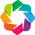

In [180]:
import holoviews as hv
hv.extension('bokeh')

In [318]:
sankey_obj = sankey_plot(MappingTable, align_thr=0.05, species_order=['hu','mu'])
sankey_obj
sankey_obj.opts(frame_width=2000, frame_height=1600)
hv.save(sankey_obj, "figures/sankey_plot.html", resources='inline')

In [319]:
sankey_obj = sankey_plot(MappingTable, align_thr=0.05, species_order=['mu','hu'])
sankey_obj
sankey_obj.opts(frame_width=2000, frame_height=1600)
hv.save(sankey_obj, "figures/sankey_plot_mu_hu_fi.html", resources='inline')

In [33]:
sankey_plot(MappingTable, align_thr=0.05, species_order = ['pl','sc','hy'])

:Sankey   [source,target]   (Value)

In [25]:
sankey_plot(MappingTable, align_thr=0.05, species_order = ['sc','pl','hy'])

:Sankey   [source,target]   (Value)

In [26]:
sankey_plot(MappingTable, align_thr=0.01, species_order = ['sc','pl','hy'])

:Sankey   [source,target]   (Value)

In [320]:
chord_obj = chord_plot(MappingTable, align_thr=0.05)
chord_obj
chord_obj.opts(width=2000, height=1600)
hv.save(chord_obj, "figures/chord_plot_humufi.html", resources='inline')

In [185]:
chord_plot(MappingTable, align_thr=0.05)

:Chord   [source,target]   (value,edge_grp)

## Visualizing the combined projection

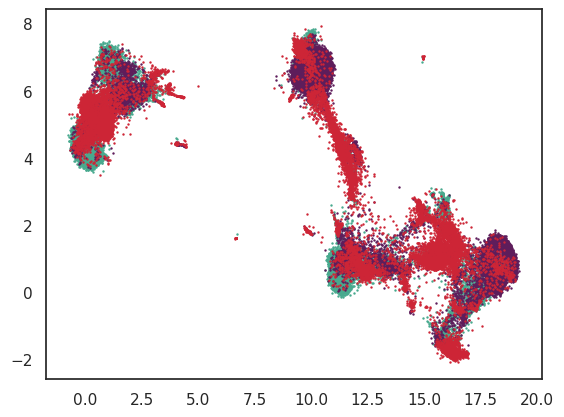

In [321]:
sm.scatter()
plt.savefig("figures/scatter.svg")

In [187]:
sm.samap.gui()

ModuleNotFoundError: No module named 'plotly'

In [39]:
sm.gui()

ImportError: Please install SAMGUI dependencies. See the README in the SAM github repository.

## 保存整合anndata及可视化

In [189]:
import scanpy as sc
import matplotlib.pyplot as plt
import networkx as nx
import umap
from scipy.sparse import csr_matrix
import seaborn as sns
import holoviews as hv

In [329]:
samap = sm.samap
adata1 = samap.adata
adata1

AnnData object with n_obs × n_vars = 41768 × 53151
    obs: 'hu_leiden_clusters', 'mu_leiden_clusters', 'fi_leiden_clusters', 'batch', 'species', 'leiden_clusters;leiden_clusters;leiden_clusters_mapping_scores', 'cell_type;cell_type;leiden_clusters_mapping_scores'
    uns: 'neighbors', 'gnnm_corr', 'mapping_K', 'umap', 'homology_gene_names_dict', 'species_colors', 'hu_leiden_clusters_colors', 'fi_leiden_clusters_colors'
    obsm: 'X_umap'
    layers: 'X_disp'
    obsp: 'connectivities'
    varp: 'homology_graph_reweighted', 'homology_graph'

In [448]:
adata = samap.adata
adata

AnnData object with n_obs × n_vars = 25298 × 31526
    obs: 'hu_cell_type', 'hu_leiden_clusters', 'mk_leiden_clusters', 'batch', 'species', 'cell_type;leiden_clusters_mapping_scores'
    uns: 'neighbors', 'gnnm_corr', 'mapping_K', 'umap', 'homology_gene_names_dict'
    obsm: 'X_umap'
    layers: 'X_disp'
    obsp: 'connectivities'
    varp: 'homology_graph_reweighted', 'homology_graph'

In [452]:
adata.obs

,hu_cell_type,hu_leiden_clusters,mk_leiden_clusters,batch,species,cell_type;leiden_clusters_mapping_scores
AAACCTGAGAGGTAGA-1_human,NK cells,1,unassigned,batch1,hu,hu_NK cells
AAACCTGAGCAAATCA-1_human,NK cells,1,unassigned,batch1,hu,hu_NK cells
AAACCTGAGCAGACTG-1_human,B cells,0,unassigned,batch1,hu,hu_B cells
AAACCTGAGCGATTCT-1_human,T cells,3,unassigned,batch1,hu,hu_T cells
AAACCTGAGCTGCAAG-1_human,T cells,4,unassigned,batch1,hu,hu_T cells
...,...,...,...,...,...,...
TTTGTCAGTGTGGCTC-1,unassigned,unassigned,0,batch2,mk,mk_0
TTTGTCATCATCATTC-1,unassigned,unassigned,8,batch2,mk,mk_8
TTTGTCATCGAATGCT-1,unassigned,unassigned,6,batch2,mk,mk_6
TTTGTCATCGCGTAGC-1,unassigned,unassigned,0,batch2,mk,mk_0


In [449]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message="No data for colormapping")

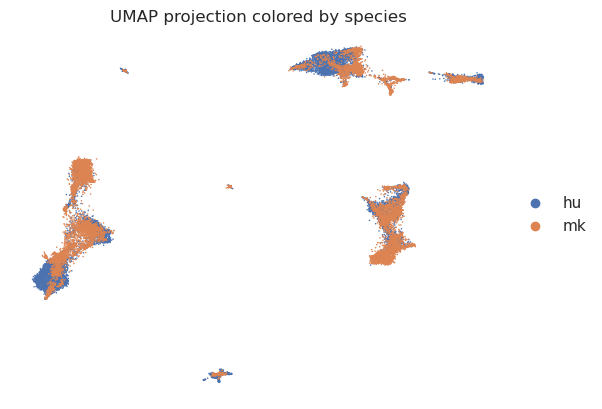

In [450]:
sc.pl.umap(adata, color=['species'], 
           title='UMAP projection colored by species', 
           frameon=False,
           save='_hu_mk.png')

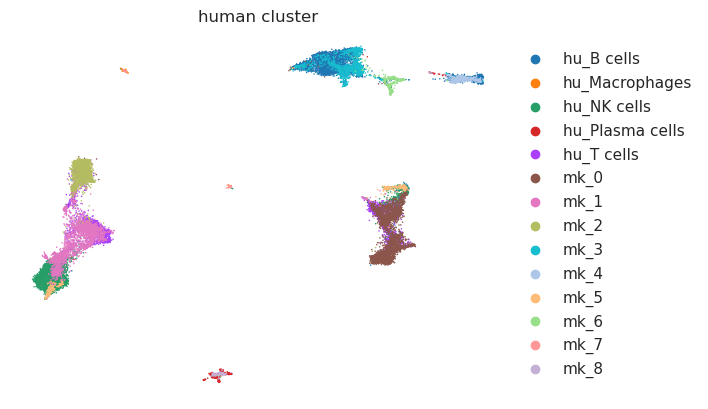

In [453]:
sc.pl.umap(adata, 
           color='cell_type;leiden_clusters_mapping_scores', 
           title='human cluster',
           frameon=False,
           save='_celltype_hu_mk.png')

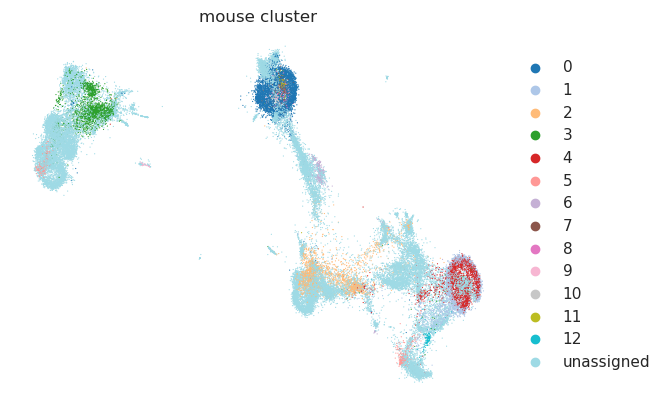

In [364]:
sc.pl.umap(adata, 
           color='mu_leiden_clusters', 
           title='mouse cluster',
           frameon=False,
           palette='tab20',
           save='_mu_cluster.svg')

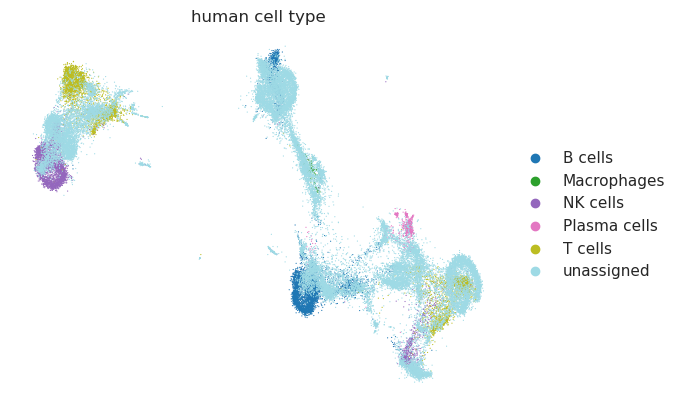

In [365]:
sc.pl.umap(adata, 
           color='hu_cell_type', 
           title='human cell type',
           palette='tab20',
           frameon=False,
           save='_hu_celltype.svg')

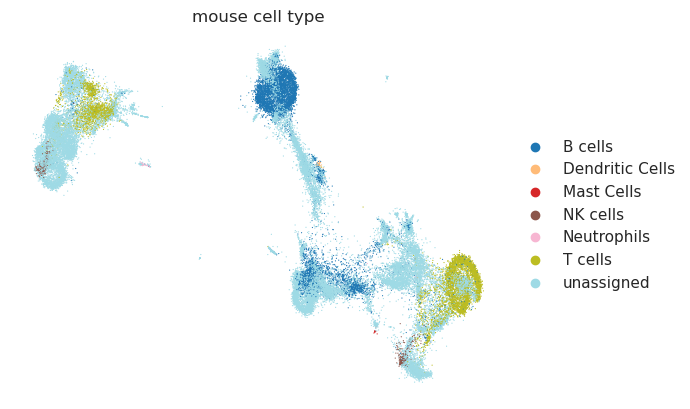

In [367]:
sc.pl.umap(adata, 
           color='mu_cell_type', 
           title='mouse cell type',
           frameon=False,
           palette='tab20',
           save='_mu_celltype.svg')

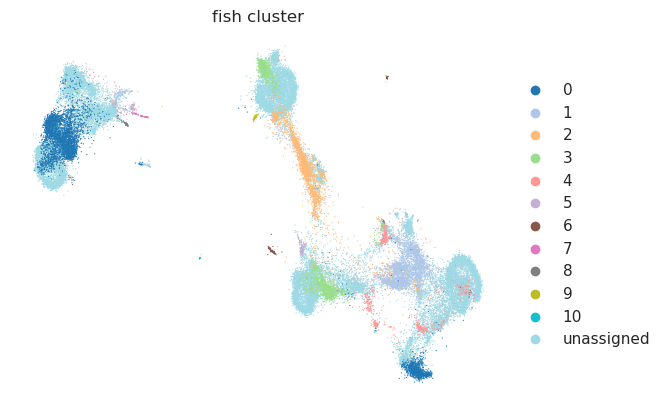

In [366]:
sc.pl.umap(adata, 
           color='fi_leiden_clusters', 
           title='fish cluster',
           frameon=False,
           palette='tab20',
           save='_fish_cluster.svg')

In [386]:
os.getcwd()

'/public/workspace/lhpeng/gwork/SAMap'

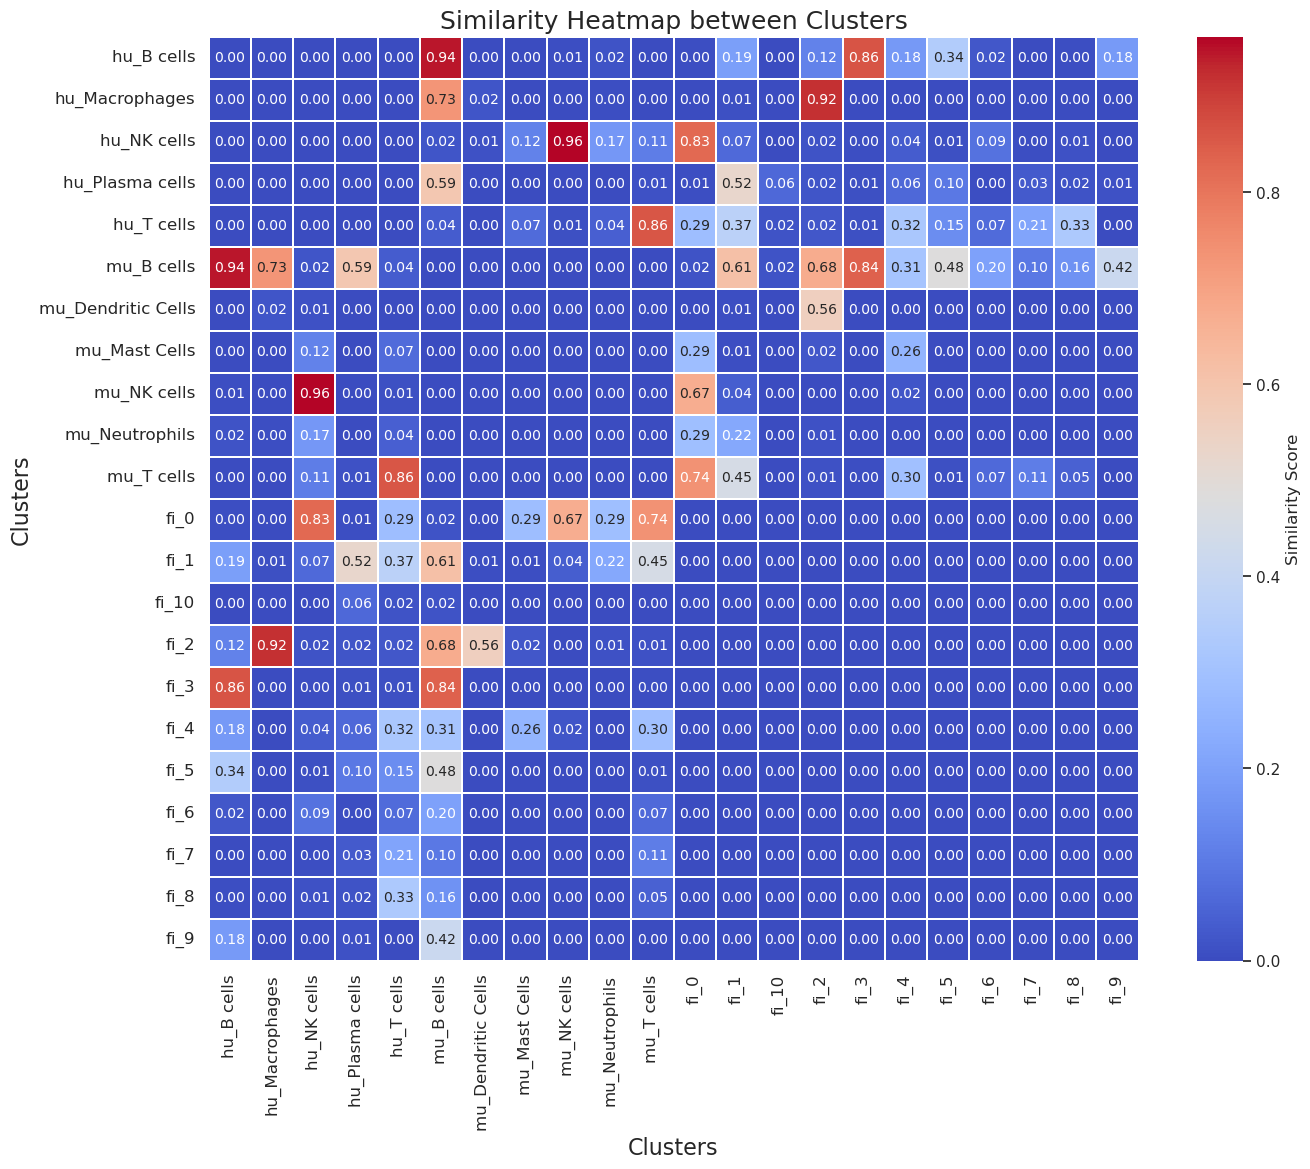

In [387]:
import seaborn as sns
import matplotlib.pyplot as plt
 
# 假设 MappingTable 是一个 Pandas DataFrame，且已经包含了相似性分数
# 如果 MappingTable 是一个 NumPy 数组，也可以直接使用
 
sns.set(style="white")
 
# 绘制热图
plt.figure(figsize=(15, 12))  # 增大热图的尺寸
sns.heatmap(
    MappingTable2,  # 数据源
    annot=True,  # 是否在热图上显示数值
    fmt=".2f",  # 数值的格式
    cmap="coolwarm",  # 色彩映射，coolwarm 是一个常见的选择
    linewidths=0.1,  # 单元格之间的分隔线宽度
    cbar_kws={"label": "Similarity Score"},  # 色标标签
    annot_kws={"size": 10},  # 设置注释的字体大小
)
 
# 设置标题和标签
plt.title("Similarity Heatmap between Clusters", fontsize=18)  # 增大标题字体大小
plt.xlabel("Clusters", fontsize=16)  # 增大X轴标签字体大小
plt.ylabel("Clusters", fontsize=16)  # 增大Y轴标签字体大小
 
# 设置坐标轴刻度标签的字体大小
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
 
# 保存可视化文件
plt.savefig("figures/samap_heatmap2.pdf", format="pdf", bbox_inches="tight")
plt.savefig("figures/samap_heatmap2.png", format="png", bbox_inches="tight")
 
# 显示热图
plt.show()
plt.close()

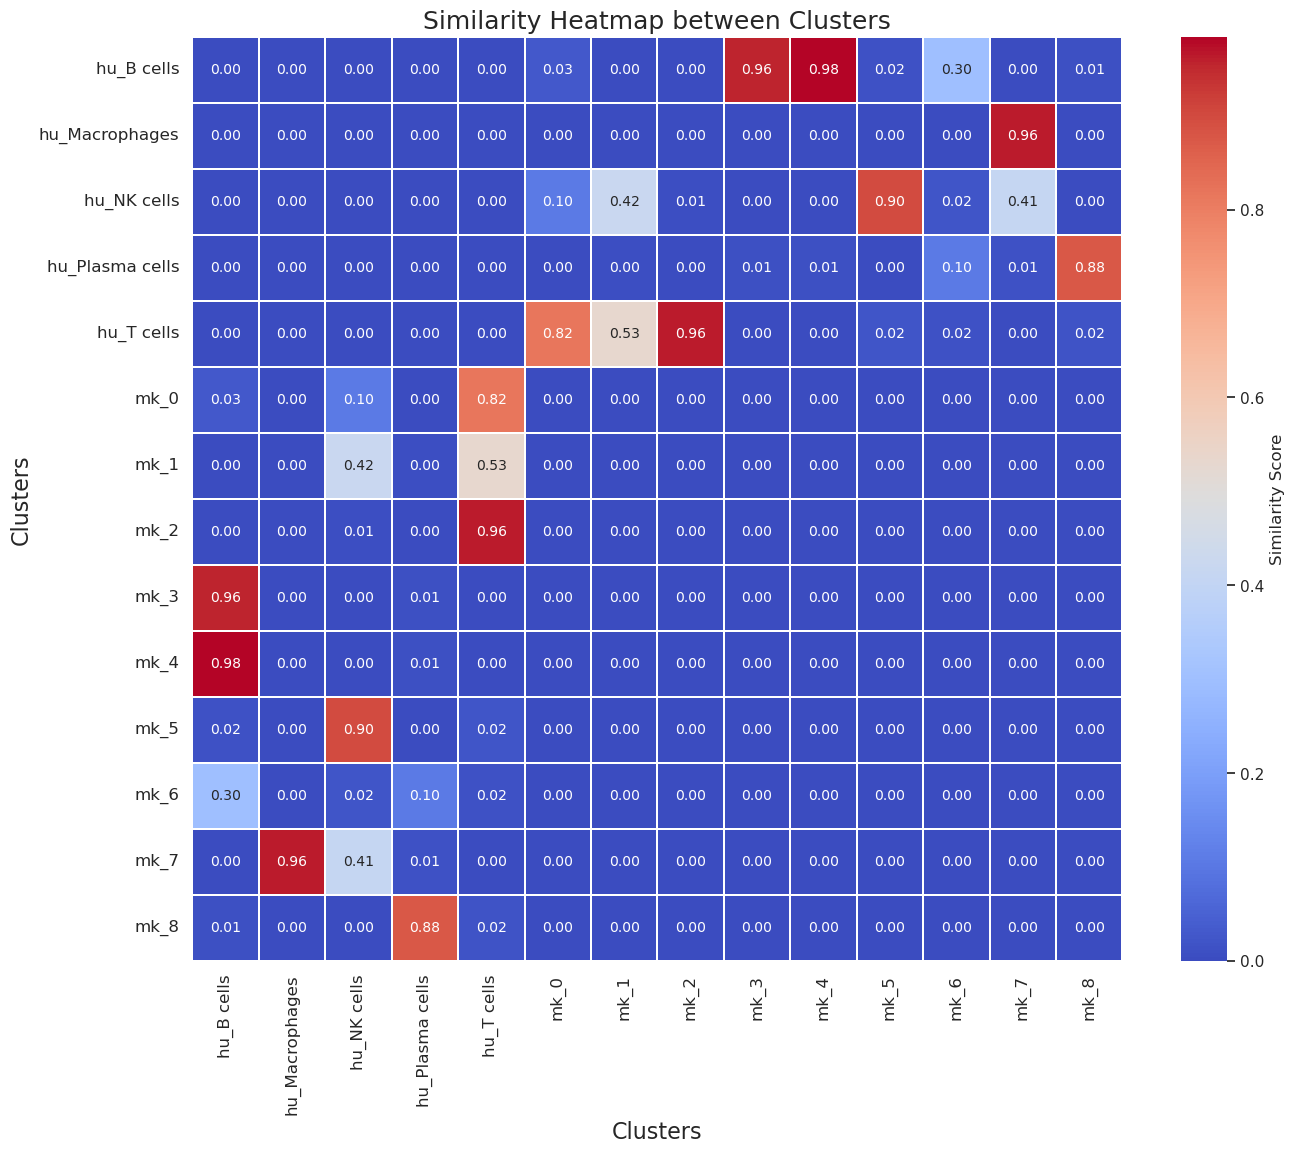

In [455]:
import seaborn as sns
import matplotlib.pyplot as plt
 
# 假设 MappingTable 是一个 Pandas DataFrame，且已经包含了相似性分数
# 如果 MappingTable 是一个 NumPy 数组，也可以直接使用
 
sns.set(style="white")
 
# 绘制热图
plt.figure(figsize=(15, 12))  # 增大热图的尺寸
sns.heatmap(
    MappingTable,  # 数据源
    annot=True,  # 是否在热图上显示数值
    fmt=".2f",  # 数值的格式
    cmap="coolwarm",  # 色彩映射，coolwarm 是一个常见的选择
    linewidths=0.1,  # 单元格之间的分隔线宽度
    cbar_kws={"label": "Similarity Score"},  # 色标标签
    annot_kws={"size": 10},  # 设置注释的字体大小
)
 
# 设置标题和标签
plt.title("Similarity Heatmap between Clusters", fontsize=18)  # 增大标题字体大小
plt.xlabel("Clusters", fontsize=16)  # 增大X轴标签字体大小
plt.ylabel("Clusters", fontsize=16)  # 增大Y轴标签字体大小
 
# 设置坐标轴刻度标签的字体大小
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
 
# 保存可视化文件
plt.savefig("figures/samap_heatmap_hu_mk.pdf", format="pdf", bbox_inches="tight")
plt.savefig("figures/samap_heatmap_hu_mk.png", format="png", bbox_inches="tight")
 
# 显示热图
plt.show()
plt.close()

### 细胞注释转移

In [456]:
df = MappingTable

In [400]:
human_cols = ['hu_B cells', 'hu_Macrophages', 'hu_NK cells', 'hu_Plasma cells', 'hu_T cells']

# 只提取 fi_* 聚类行
fi_clusters = [idx for idx in df.index if idx.startswith('fi_')]
df_fi = df.loc[fi_clusters, human_cols]

# 每个fi聚类：在人类类型中取最高分
fi_best_hu = df_fi.idxmax(axis=1)

# 去掉 hu_ 前缀，统一名称
fi_map = {idx: col.replace('hu_', '') for idx, col in fi_best_hu.items()}

print("✅ 严格按 hu_* 分数自动注释结果：")
for k, v in fi_map.items():
    print(f"{k} → {v}")

✅ 严格按 hu_* 分数自动注释结果：
fi_0 → NK cells
fi_1 → Plasma cells
fi_10 → Plasma cells
fi_2 → Macrophages
fi_3 → B cells
fi_4 → T cells
fi_5 → B cells
fi_6 → NK cells
fi_7 → T cells
fi_8 → T cells
fi_9 → B cells


In [405]:
def unified_cell_type(row):
    # 人：直接用原有注释
    if row['species'] == 'hu':
        return row['hu_cell_type']
    
    # 小鼠：去掉mu_前缀，统一成人的命名
    elif row['species'] == 'mu':
        return row['mu_cell_type'].replace('mu_', '')
    
    # 鱼：把 0 → fi_0，1→fi_1，完美匹配注释字典
    elif row['species'] == 'fi':
        cluster_num = str(row['fi_leiden_clusters'])  # 拿到 0,1,2...
        cluster_name = f"fi_{cluster_num}"            # 变成 fi_0, fi_1...
        return fi_map.get(cluster_name, 'Unknown')
    
    # 其他情况
    else:
        return 'Unknown'

# ----------------------
# 3. 生成三物种统一细胞类型
# ----------------------
adata.obs['cell_type_unified'] = adata.obs.apply(unified_cell_type, axis=1)

['B cells', 'Dendritic Cells', 'Macrophages', 'Mast Cells', 'NK cells', 'Neutrophils', 'Plasma cells', 'T cells']


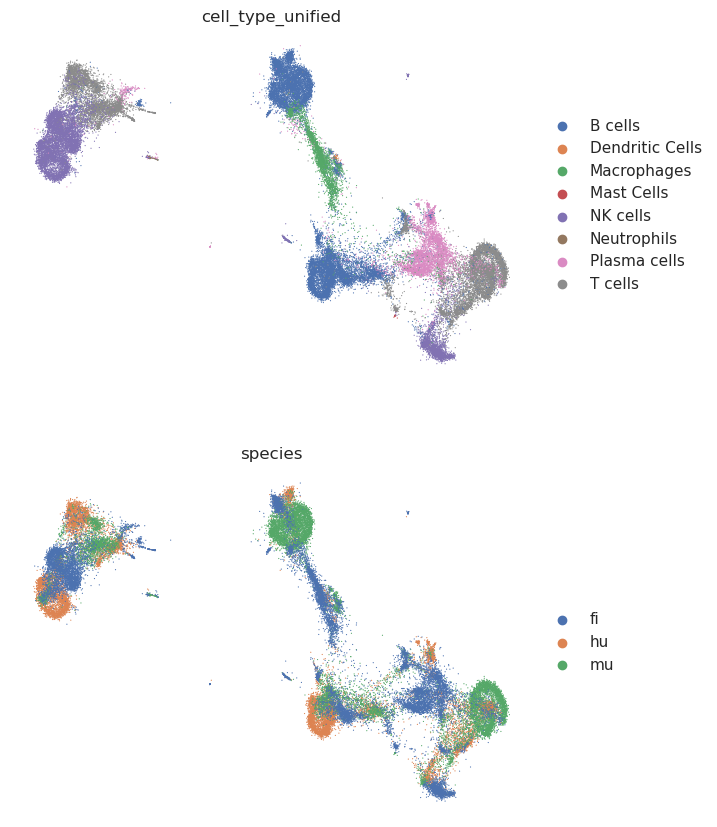

In [406]:
# 查看所有统一细胞类型
print(sorted(adata.obs['cell_type_unified'].unique()))

# 统计分布
pd.crosstab(adata.obs['species'], adata.obs['cell_type_unified'])

# UMAP
sc.pl.umap(adata, color=['cell_type_unified', 'species'], frameon=False, ncols=1)

In [403]:
import pandas as pd

def get_cluster_to_celltype(df, ref_prefix='hu_', cluster_prefix='fi_'):
    """
    通用函数：根据分数表格，自动将聚类ID映射到最高分的参考细胞类型
    参数：
        df: 分数表格 DataFrame
        ref_prefix: 参考细胞类型前缀，如 'hu_' / 'mu_'
        cluster_prefix: 需要注释的聚类前缀，如 'fi_' / 'leiden_'
    返回：
        聚类 → 细胞类型 的字典
    """
    # 自动筛选参考列（根据前缀）
    ref_cols = [col for col in df.columns if col.startswith(ref_prefix)]
    
    # 自动筛选需要注释的聚类行
    clusters = [idx for idx in df.index if idx.startswith(cluster_prefix)]
    
    # 提取分数子矩阵
    sub_df = df.loc[clusters, ref_cols]
    
    # 每个聚类取最高分
    best_ct = sub_df.idxmax(axis=1)
    
    # 去掉前缀，得到干净的细胞类型名
    mapping = {idx: col.replace(ref_prefix, '') for idx, col in best_ct.items()}
    
    return mapping

In [407]:
mu_map = get_cluster_to_celltype(df, ref_prefix='hu_', cluster_prefix='mu_')

In [457]:
mk_map = get_cluster_to_celltype(df, ref_prefix='hu_', cluster_prefix='mk_')

In [409]:
def unified_cell_type(row):
    # 人：直接用注释
    if row['species'] == 'hu':
        return row['hu_cell_type']
    
    # 小鼠：从 mu_map 字典取（按人类分数注释）
    elif row['species'] == 'mu':
        cluster_id = str(row['mu_leiden_clusters'])
        cluster_name = f"mu_{cluster_id}"  # 拼成 mu_0, mu_1...
        return mu_map.get(cluster_name, 'Unknown')
    
    # 斑马鱼：从 fi_map 字典取（按人类分数注释）
    elif row['species'] == 'fi':
        cluster_id = str(row['fi_leiden_clusters'])
        cluster_name = f"fi_{cluster_id}"  # 拼成 fi_0, fi_1...
        return fi_map.get(cluster_name, 'Unknown')
    
    else:
        return 'Unknown'

# ----------------------
# 3. 生成最终统一细胞类型
# ----------------------
adata.obs['cell_type_unified'] = adata.obs.apply(unified_cell_type, axis=1)

In [421]:
def unified_cell_type(row):
    # 人：直接用自身注释
    if row['species'] == 'hu':
        return row['hu_cell_type']
    
    # 小鼠：【特殊处理】用你给的固定字典
    elif row['species'] == 'mu':
        mu_key = f"mu_{row['mu_cell_type']}"
        return mu_map.get(mu_key, 'Unknown')
    
    # 斑马鱼：用分数表注释
    elif row['species'] == 'fi':
        cluster_id = str(row['fi_leiden_clusters'])
        cluster_name = f"fi_{cluster_id}"
        return fi_map.get(cluster_name, 'Unknown')
    
    else:
        return 'Unknown'

# ----------------------
# 4. 生成统一细胞类型
# ----------------------
adata.obs['cell_type_unified'] = adata.obs.apply(unified_cell_type, axis=1)

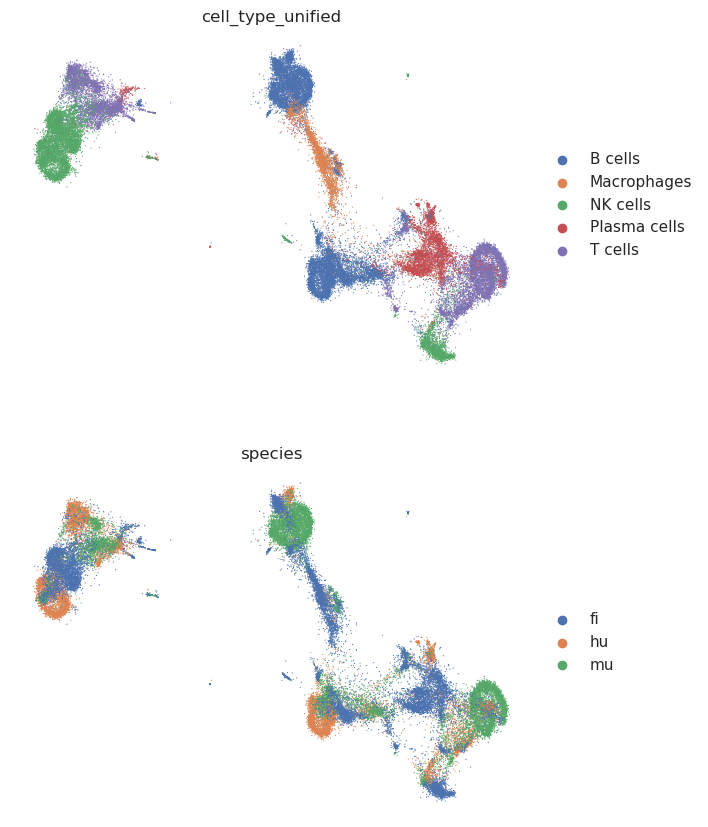

In [426]:
sc.pl.umap(adata, 
           color=['cell_type_unified', 'species'], 
           frameon=False, 
           ncols=1,
           save="_cell_type_unified.png")

In [458]:
def unified_cell_type(row):
    # 人：直接用注释
    if row['species'] == 'hu':
        return row['hu_cell_type']

    elif row['species'] == 'mk':
        cluster_id = str(row['mk_leiden_clusters'])
        cluster_name = f"fi_{cluster_id}"  # 拼成 fi_0, fi_1...
        return fi_map.get(cluster_name, 'Unknown')
    
    else:
        return 'Unknown'

# ----------------------
# 3. 生成最终统一细胞类型
# ----------------------
adata.obs['cell_type_unified'] = adata.obs.apply(unified_cell_type, axis=1)

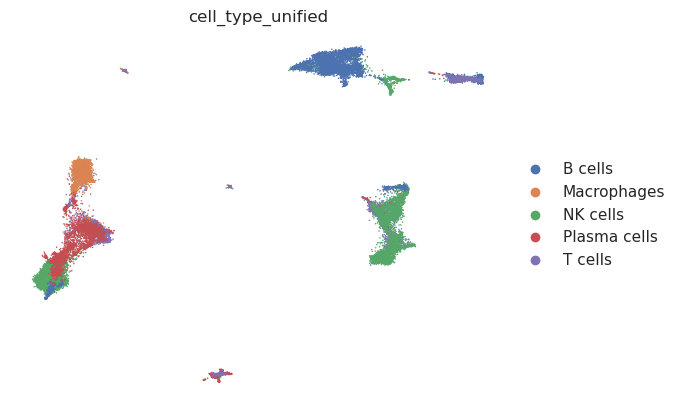

In [460]:
sc.pl.umap(adata, 
           color='cell_type_unified', 
           frameon=False, 
           ncols=1,
           save="_cell_type_unified_hu_mk.png")

## 0

User-specified cell type annotations can be used in place of leiden clustering by specifying the `keys` parameter in `SAMAP`. For example, let's use 'cluster' in planarian, 'Cluster' in hydra, and 'tissue' in schistosome:

In [11]:
sm.sams['pl'].adata.obs['cluster'].head()

index
Cells_Trunk_TGAGCAGGTATT    Intestine: 6
Cells_Trunk_CTCGAACCAAAG    Intestine: 6
Cells_Trunk_ATCTAGTCGACN     Neoblast: 0
Cells_Trunk_CTTTGAAAATCT    Epidermal: 2
Cells_Trunk_CCTTTTAGAACT     Neoblast: 0
Name: cluster, dtype: category
Categories (42, object): ['Cathepsin+ cells: 4', 'Cathepsin+ cells: 10', 'Cathepsin+ cells: 15', 'Cathepsin+ cells: 17', ..., 'Pharynx: 37', 'Protonephridia: 26', 'Protonephridia: 29', 'Protonephridia: 40']

In [12]:
sm.sams['hy'].adata.obs['Cluster'].head()

index
03-MA_GCTAAAGCCACN    i_mgl
03-MA_CCCTATCCTGGG    i_mgl
03-MA_TGCAGTCCTGCC    i_mgl
03-MA_GCCCTGAAACCA    i_mgl
03-FM_AGGTTGGTCTTA    i_mgl
Name: Cluster, dtype: category
Categories (42, object): ['ecEp_SC2', 'ecEp_SC3', 'ecEp_bat1(mp)', 'ecEp_bat2(mp)', ..., 'i_smgc2', 'i_zmg1', 'i_zmg2', 'nan']

In [13]:
sm.sams['sc'].adata.obs['tissue'].head()

index
YX_1009901001_B20       Muscle
YX_1009901001_B4     Cathepsin
YX_1009901001_C23     Neoblast
YX_1009901001_C8        Neural
YX_1009901001_D2        Muscle
Name: tissue, dtype: category
Categories (11, object): ['Cathepsin', 'Flame cells', 'Gland', 'Intestine', ..., 'Neural_KK7', 'Parenchymal', 'Tegument', 'Tegument_prog']

Finally, rather than determining neighborhood sizes by hopping along each cell's outgoing edges, we can also determine them using the cell type labels. In other words, cells that have the same label all belong to the same neighborhood. This can be set using the `neigh_from_keys` parameter of `SAMAP.run`.

In [21]:
keys = {'pl':'cluster','hy':'Cluster','sc':'tissue'}
D,MappingTable = get_mapping_scores(sm,keys,n_top = 0)

In [22]:
D.head()

sc_Muscle                     pl_Muscle: 14                  \
            Cluster Alignment score           Cluster Alignment score   
0     pl_Muscle: 14        0.979533         sc_Muscle        0.979533   
1     pl_Muscle: 13        0.979246  hy_enEp_tent(pd)        0.492931   
2  hy_enEp_tent(pd)        0.900845      hy_enEp_tent        0.470203   
3      hy_enEp_tent        0.862918      hy_enEp_foot        0.246056   
4     pl_Muscle: 16        0.835806  hy_enEp_nem1(pd)        0.078529   

      pl_Muscle: 13                      sc_Neoblast                  \
            Cluster Alignment score          Cluster Alignment score   
0         sc_Muscle        0.979246  pl_Neoblast: 22        0.971357   
1  hy_enEp_tent(pd)        0.431385   pl_Neoblast: 0        0.969782   
2      hy_enEp_tent        0.388073         hy_i_nb1        0.780167   
3      hy_enEp_foot        0.162294          hy_i_SC        0.772084   
4  hy_enEp_nem1(pd)        0.053982       hy_i_fmgl1        0.712123   

   pl_Neoblast: 22                  ... pl_Protonephridia: 26                  \
           Cluster Alignment score  ...               Cluster Alignment score   
0      sc_Neoblast        0.971357  ...        sc_Parenchymal        0.120032   
1          hy_i_SC        0.621404  ...        sc_Flame cells        0.037039   
2       hy_i_fmgl1        0.138634  ...              hy_i_nb3        0.017052   
3         hy_i_nb1        0.134065  ...             sc_Neural        0.015401   
4  hy_i_nc_gc_prog        0.077265  ...           sc_Neoblast        0.006779   

                hy_i_nb4                        hy_ecEp_bd                  \
                 Cluster Alignment score           Cluster Alignment score   
0            sc_Neoblast        0.117042  pl_Epidermal: 11        0.108307   
1           pl_Neural: 1        0.111219       sc_Tegument        0.071388   
2              sc_Neural        0.102364  pl_Epidermal: 24        0.068627   
3         sc_Parenchymal        0.050168  sc_Tegument_prog        0.030188   
4  pl_Parapharyngeal: 12        0.044167    pl_Pharynx: 25        0.003685   

                sc_Gland                   sc_Neural_KK7                  
                 Cluster Alignment score         Cluster Alignment score  
0              hy_i_zmg1        0.081807    pl_Neural: 1         0.03604  
1       pl_Epidermal: 11        0.069297  pl_Neoblast: 0        0.031975  
2              hy_i_zmg2        0.061864     hy_enEp_SC1        0.029548  
3  pl_Parapharyngeal: 12        0.058096   pl_Muscle: 13        0.027496  
4        pl_Epidermal: 3        0.037061   pl_Muscle: 14        0.025279  

[5 rows x 190 columns]

In [18]:
MappingTable.head()

,pl_Cathepsin+ cells: 10,pl_Cathepsin+ cells: 15,pl_Cathepsin+ cells: 17,pl_Cathepsin+ cells: 28,pl_Cathepsin+ cells: 31,pl_Cathepsin+ cells: 39,pl_Cathepsin+ cells: 4,pl_Cathepsin+ cells: 41,pl_Epidermal: 11,pl_Epidermal: 2,...,hy_i_nc7,hy_i_nc8,hy_i_nc_gc_prog,hy_i_nc_prog,hy_i_nem,hy_i_smgc1,hy_i_smgc2,hy_i_zmg1,hy_i_zmg2,hy_nan
pl_Cathepsin+ cells: 10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.011634,0.004666,0.0,0.0,0.066409
pl_Cathepsin+ cells: 15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.003307,0.001222,0.0,0.0,0.018394
pl_Cathepsin+ cells: 17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.007064,0.003851,0.0,0.0,0.052715
pl_Cathepsin+ cells: 28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.002499,0.001400,0.0,0.0,0.030076
pl_Cathepsin+ cells: 31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.004065,0.003593,0.0,0.0,0.016555


The `n_top` parameter can be used to identify strongly-mapping subpopulations between clusters. If `n_top=0`, the alignment score will be averaged over all cells between two clusters. Otherwise, the alignment score will be averaged over the top `n_top` cells.

For example, let's say there are 100 / 1000 cells in Cluster A that maps to a Cluster B in the other species. On average, the mapping score between cluster A and B will be small, because there are only a few cells in cluster A that map to cluster B. If we set `n_top` to 100, then the alignment score between A and B will be averaged over the 100 highest-scoring cells. As a result, the mapping score between A and B will be large.

By default, `n_top=0`.

We can display a sankey plot to visualize mapping scores. Since the sankey plot is inherently a 2D visualization tool, we can only use it to visualize a linear set of connections. For example, in the first diagram below, the connections between planarian and hydra cell types are not shown.

- The linear species ordering can be specified by using `species_order`.
- `align_thr=0.05` zeros out mappings with alignment scores less than 0.05

In [25]:
sankey_plot(MappingTable, align_thr=0.05, species_order = ['pl','sc','hy'])

:Sankey   [source,target]   (Value)

In [21]:
sankey_plot(MappingTable, align_thr=0.05, species_order = ['sc','pl','hy'])

:Sankey   [source,target]   (Value)

We can visualize the connections between all pairs of species by using a chord plot (although it's not as interactive):

In [22]:
chord_plot(MappingTable, align_thr=0.05)

:Chord   [source,target]   (value,edge_grp)

Note that planarians and schistosomes are much more similar to each other than they are to hydra (which is expected, of course). As a result, mapping scores to hydra will tend to be smaller.

## Finding gene pairs that are enriched in pairs of cell types

In [370]:
gpf = GenePairFinder(sm2,keys=keys)

Finding cluster-specific markers in hu:cell_type.
Finding cluster-specific markers in mu:cell_type.
Finding cluster-specific markers in fi:leiden_clusters.


In [195]:
sam1.adata.obs

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,umi_gene_ratio
AAACCTGAGAGGTAGA-1,1310,2957.0,218.0,7.372337,2.257252
AAACCTGAGCAAATCA-1,1224,2434.0,150.0,6.162695,1.988562
AAACCTGAGCAGACTG-1,1850,6834.0,451.0,6.599356,3.694054
AAACCTGAGCGATTCT-1,1384,3115.0,252.0,8.089888,2.250723
AAACCTGAGCTGCAAG-1,1140,2710.0,160.0,5.904059,2.377193
...,...,...,...,...,...
TTTGTCATCGCCGTGA-1,1431,4638.0,172.0,3.708495,3.241090
TTTGTCATCGCTAGCG-1,1436,3523.0,304.0,8.629009,2.453343
TTTGTCATCTATCCTA-1,1614,5662.0,254.0,4.486047,3.508055
TTTGTCATCTTGCCGT-1,1383,3345.0,220.0,6.576981,2.418655


In [42]:
n1 = 'pl_Neoblast: 0' #cell type ID from organism 1 (must be present in `sam1.adata.obs[k1]`)
n2 = 'sc_Neoblast' #cell type ID from organism 2 (must be present in `sam2.adata.obs[k1]`)
Gp,G1,G2,pvals1,pvals2 = gpf.find_genes(n1,n2)
#Gp are the gene pairs, G1 are the genes from organism 1, G2 are the genes from organism 2,
#pvals1 are p-values from organism 1, and pvals2 are p-values from organism 2.

In [43]:
Gp[:5],G1[:5],G2[:5],pvals1[:5],pvals2[:5]

(array(['pl_dd_Smed_v4_659_0_1;sc_Smp_179320',
        'pl_dd_Smed_v4_2614_0_1;sc_Smp_086860',
        'pl_dd_Smed_v4_648_0_1;sc_Smp_027920',
        'pl_dd_Smed_v4_2787_0_1;sc_Smp_086860',
        'pl_dd_Smed_v4_7837_0_1;sc_Smp_082490'], dtype='<U37'),
 array(['pl_dd_Smed_v4_659_0_1', 'pl_dd_Smed_v4_2614_0_1',
        'pl_dd_Smed_v4_648_0_1', 'pl_dd_Smed_v4_2787_0_1',
        'pl_dd_Smed_v4_7837_0_1'], dtype='<U23'),
 array(['sc_Smp_179320', 'sc_Smp_086860', 'sc_Smp_027920', 'sc_Smp_082490',
        'sc_Smp_162370'], dtype='<U13'),
 array([2.15546458e-58, 7.59624616e-16, 1.41001717e-56, 5.12123753e-17,
        2.84207093e-15]),
 array([1.60607435e-93, 7.54689830e-99, 1.54112467e-80, 7.54689830e-99,
        1.16734960e-95]))

To get a table of enriched gene pairs from all cell type mappings that have an alignment score above some threshold (`align_thr`), you can use:

In [371]:
gene_pairs = gpf.find_all(align_thr=0.2)

Calculating gene pairs for the mapping: fi;0 to hu;NK cells
Calculating gene pairs for the mapping: fi;0 to hu;T cells
Calculating gene pairs for the mapping: fi;0 to mu;Mast Cells
Calculating gene pairs for the mapping: fi;0 to mu;NK cells
Calculating gene pairs for the mapping: fi;0 to mu;Neutrophils
Calculating gene pairs for the mapping: fi;0 to mu;T cells
Calculating gene pairs for the mapping: fi;1 to hu;Plasma cells
Calculating gene pairs for the mapping: fi;1 to hu;T cells
Calculating gene pairs for the mapping: fi;1 to mu;B cells
Calculating gene pairs for the mapping: fi;1 to mu;Neutrophils
Calculating gene pairs for the mapping: fi;1 to mu;T cells
Calculating gene pairs for the mapping: fi;2 to hu;Macrophages
Calculating gene pairs for the mapping: fi;2 to mu;B cells
Calculating gene pairs for the mapping: fi;2 to mu;Dendritic Cells
Calculating gene pairs for the mapping: fi;3 to hu;B cells
Calculating gene pairs for the mapping: fi;3 to mu;B cells
Calculating gene pairs for

Calculating gene pairs for the mapping: pl;Neural: 18 to sc;Neural
Calculating gene pairs for the mapping: pl;Neural: 20 to sc;Neural
Calculating gene pairs for the mapping: pl;Neural: 21 to sc;Neural
Calculating gene pairs for the mapping: pl;Neural: 23 to sc;Neural
Calculating gene pairs for the mapping: pl;Neural: 32 to sc;Parenchymal
Calculating gene pairs for the mapping: pl;Neural: 33 to sc;Neural
Calculating gene pairs for the mapping: pl;Neural: 34 to sc;Neural
Calculating gene pairs for the mapping: pl;Neural: 36 to sc;Neural
Calculating gene pairs for the mapping: pl;Neural: 36 to sc;Parenchymal
Calculating gene pairs for the mapping: pl;Neural: 8 to sc;Neural
Calculating gene pairs for the mapping: pl;Neural: 9 to sc;Neural
Calculating gene pairs for the mapping: pl;Parapharyngeal: 12 to sc;Parenchymal
Calculating gene pairs for the mapping: pl;Parapharyngeal: 38 to sc;Parenchymal
Calculating gene pairs for the mapping: pl;Pharynx: 27 to sc;Flame cells


In [372]:
gene_pairs.head()

,fi_0;hu_NK cells,fi_0;hu_NK cells_pval1,fi_0;hu_NK cells_pval2,fi_0;hu_T cells,fi_0;hu_T cells_pval1,fi_0;hu_T cells_pval2,fi_0;mu_Mast Cells,fi_0;mu_Mast Cells_pval1,fi_0;mu_Mast Cells_pval2,fi_0;mu_NK cells,...,hu_Macrophages;mu_B cells_pval2,hu_NK cells;mu_NK cells,hu_NK cells;mu_NK cells_pval1,hu_NK cells;mu_NK cells_pval2,hu_Plasma cells;mu_B cells,hu_Plasma cells;mu_B cells_pval1,hu_Plasma cells;mu_B cells_pval2,hu_T cells;mu_T cells,hu_T cells;mu_T cells_pval1,hu_T cells;mu_T cells_pval2
0,fi_s1pr4;hu_S1PR5,0.0,0.0,fi_ccr9a;hu_CXCR6,0.0,0.0,fi_ccr9a;mu_C5ar1,0.0,0.000268,fi_s1pr4;mu_S1pr5,...,0.0,hu_GZMB;mu_Gzma,0.0,0.0,hu_MZB1;mu_Mzb1,0.0,0.0,hu_CD3D;mu_Cd3d,0.0,0.0
1,fi_ccr9a;hu_CX3CR1,0.0,0.0,fi_arpc5b;hu_ARPC5L,0.0,0.0,fi_ccr9a;mu_Cxcr2,0.0,0.001093,fi_anxa11b;mu_Anxa2,...,0.000006,hu_GZMH;mu_Gzma,0.0,0.0,hu_HSP90B1;mu_Hsp90b1,0.0,0.0,hu_CD3D;mu_Cd3g,0.0,0.0
2,fi_anxa11b;hu_ANXA1,0.000165,0.0,fi_cdc42l;hu_RHOH,0.001965,0.0,fi_anxa11b;mu_Anxa1,0.000165,0.000109,fi_anxa4;mu_Anxa2,...,0.0,hu_KLRF1;mu_Klrb1c,0.0,0.0,hu_IGLL5;mu_H2-Eb1,0.0,0.0,hu_CD3G;mu_Cd3d,0.0,0.0
3,fi_arpc2;hu_ARPC2,0.007157,0.0,fi_ccr9a;hu_GPR174,0.0,0.0,fi_anxa4;mu_Anxa1,0.000069,0.000109,fi_serpinb1l1;mu_Serpinb9,...,0.002201,hu_KLRF1;mu_Klrk1,0.0,0.0,hu_SEC11C;mu_Sec11c,0.0,0.0,hu_CD3G;mu_Cd3g,0.0,0.0
4,fi_s1pr4;hu_S1PR1,0.0,0.0,fi_cdc42l;hu_RHOG,0.001965,0.0,fi_arpc1b;mu_Arpc1a,0.0,0.000523,fi_fcer1g;mu_Fcer1g,...,0.0,hu_LAIR2;mu_Ncr1,0.0,0.0,hu_PDIA4;mu_Pdia4,0.0,0.0,hu_CD3E;mu_Cd3e,0.0,0.0


In [373]:
gene_pairs.to_csv("gene_pairs_all_0.2.csv")

To get a table of gene pairs enriched in all cell types conected to schistosome muscle cells, we can use:

In [376]:
gene_pairs = gpf.find_all(n='hu_T cells', align_thr=0.2)

Calculating gene pairs for the mapping: fi;0 to hu;T cells
Calculating gene pairs for the mapping: fi;1 to hu;T cells
Calculating gene pairs for the mapping: fi;4 to hu;T cells
Calculating gene pairs for the mapping: fi;7 to hu;T cells
Calculating gene pairs for the mapping: fi;8 to hu;T cells
Calculating gene pairs for the mapping: hu;T cells to mu;T cells


In [377]:
gene_pairs.head()

,fi_0;hu_T cells,fi_0;hu_T cells_pval1,fi_0;hu_T cells_pval2,fi_1;hu_T cells,fi_1;hu_T cells_pval1,fi_1;hu_T cells_pval2,fi_4;hu_T cells,fi_4;hu_T cells_pval1,fi_4;hu_T cells_pval2,fi_7;hu_T cells,fi_7;hu_T cells_pval1,fi_7;hu_T cells_pval2,fi_8;hu_T cells,fi_8;hu_T cells_pval1,fi_8;hu_T cells_pval2,hu_T cells;mu_T cells,hu_T cells;mu_T cells_pval1,hu_T cells;mu_T cells_pval2
0,fi_ccr9a;hu_CXCR6,0.0,0.0,fi_krt8;hu_VIM,0.0,0.0,fi_junbb;hu_JUNB,0.00041,0.0,fi_hmgb2b;hu_HMGB2,0.000525,0.0,fi_lpp;hu_ZYX,0.002744,0.0,hu_CD3D;mu_Cd3d,0.0,0.0
1,fi_arpc5b;hu_ARPC5L,0.0,0.0,fi_ssr2;hu_SSR2,0.009217,0.000001,fi_junba;hu_JUNB,0.0,0.0,fi_rps27l;hu_RPS27L,0.000016,0.0,fi_pim2;hu_CAMK4,0.0,0.0,hu_CD3D;mu_Cd3g,0.0,0.0
2,fi_cdc42l;hu_RHOH,0.001965,0.0,fi_eif3k;hu_EIF3K,0.000007,0.001043,fi_jun;hu_JUNB,0.000288,0.0,fi_mycbp;hu_MYCBP,0.002125,0.001081,fi_pim2;hu_PASK,0.0,0.0,hu_CD3G;mu_Cd3d,0.0,0.0
3,fi_ccr9a;hu_GPR174,0.0,0.0,fi_calm3a;hu_CALM3,0.0,0.0,fi_junbb;hu_JUN,0.00041,0.0,fi_cops9;hu_COPS9,0.002768,0.0,fi_myh11a;hu_MYH9,0.000002,0.0,hu_CD3G;mu_Cd3g,0.0,0.0
4,fi_cdc42l;hu_RHOG,0.001965,0.0,fi_ncl;hu_NCL,0.0,0.002521,fi_ncl;hu_NCL,0.000248,0.002521,fi_ptp4a2a;hu_PTP4A2,0.00701,0.0,fi_il6st;hu_IL6ST,0.009651,0.0,hu_CD3E;mu_Cd3e,0.0,0.0


In [378]:
gene_pairs.to_csv("gene_pairs_hu_Tcell_0.2.csv")

## Plotting expression overlap

Let's plot the expression overlap between three genes taken from the above table: `dd_Smed_v4_9529_0_1`,`Smp_136710`, and `t13067aep`. These genes are enriched in the muscle cells across the three species.

Species-specific colors can be specified by hex codes using a dictionary keyed by the species IDs (e.g. `COLORS={'pl':'#000000',...}`). By default, colors are chosen randomly. By default, cells are colored cyan when they are overlapping in expression with the genes from other species (`COLORC='#00ceb5'`). The bottom layer show all cells colored in gray.

<Axes: >

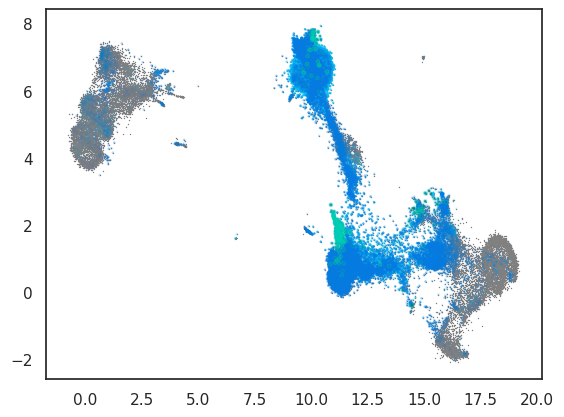

In [380]:
sm2.plot_expression_overlap({'hu':'CD79A','mu':'Cd79a','fi':'cd79a'})

Or showing overlap of genes from only two species:

/public/workspace/lhpeng/miniconda3/envs/SAMap/lib/python3.9/site-packages/samalg/__init__.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = axes.scatter(


<Axes: >

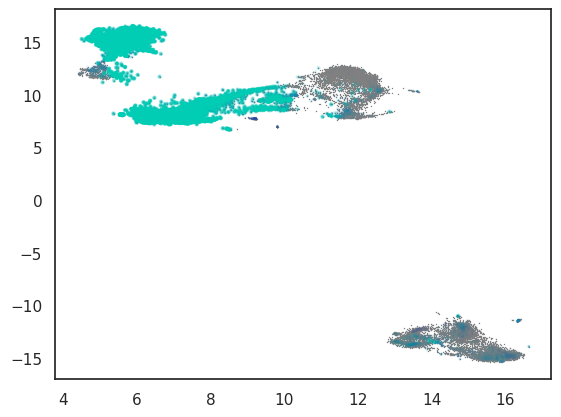

In [209]:
sm.plot_expression_overlap({'hu':'CD79A','mu':'Cd79a'})

## Identifying cell type triangles

To identify robust cell type mappings, it might be useful to find all mappings that are involved in closed triangles (meaning the three cell types all mutually map to each other).

In [381]:
#keys = {'hu':'leiden_clusters','mu':'leiden_clusters','fi':'leiden_clusters'}
result = CellTypeTriangles(sm2,keys,align_thr=0.05)

In [382]:
result.head()

,hu,mu,fi
0,hu_NK cells,mu_Mast Cells,fi_0
1,hu_NK cells,mu_NK cells,fi_0
2,hu_NK cells,mu_Neutrophils,fi_0
3,hu_NK cells,mu_T cells,fi_0
4,hu_T cells,mu_Mast Cells,fi_0


In [383]:
result.to_csv('CellTypeTriangles_humufi.csv')

## Identifying paralog substitution events

Paralog substitution events are cases in which paralogs across species have more similar expression patterns than orthologs.

SAMap provides tools to identify such events, but first we need to determine which gene paris are orthologs and which are paralogs. Here, we'll define paralogs as genes whose most recent common ancestor is the eukaryote and orthologs as genes whose most recent common ancestors are bilaterians.

This information can be obtained by using EGGNOG, which maps each transcript to a set of orthology groups in its database. I provide precomputed eggnog tables in `example_data/eggnog/`.

In [51]:
A=pd.read_csv('example_data/eggnog/planarian.tsv',sep='\t',index_col=0)
B=pd.read_csv('example_data/eggnog/schistosome.tsv',sep='\t',index_col=0)
C=pd.read_csv('example_data/eggnog/hydra.tsv',sep='\t',index_col=0)

In [52]:
A.head()

,1,2,3,4,5,6,7,8,9,10,...,12,13,14,15,16,17,eggNOG_OGs,19,KOG,21
dd_Smed_v4_10001_0_1,6412.HelroP88781,4.000000e-25,122.1,Bilateria,STK19,"GO:0003674,GO:0003824,GO:0004672,GO:0004674,GO...",2.7.11.1,ko:K08880,NaN,NaN,...,NaN,"ko00000,ko01000,ko01001",NaN,NaN,NaN,Metazoa,"296WV@1,2RDW5@2759,38QQK@33154,3BI2B@33208,3CT...",NA|NA|NA,S,kinase 19
dd_Smed_v4_10002_0_1,13735.ENSPSIP00000012485,5.000000e-22,111.7,Testudines,GNPTG,"GO:0000139,GO:0003674,GO:0005488,GO:0005515,GO...",NaN,ko:K10087,"ko04142,map04142",NaN,...,NaN,"ko00000,ko00001,ko04091",NaN,NaN,NaN,Metazoa,"38GXK@33154,3BHNW@33208,3CZKV@33213,47ZE5@7711...",NA|NA|NA,T,Glucosidase II beta subunit-like protein
dd_Smed_v4_10003_0_1,7739.XP_002612462.1,1.600000e-56,227.3,Chordata,TMX3,"GO:0002576,GO:0003674,GO:0003756,GO:0003824,GO...",5.3.4.1,ko:K09585,NaN,NaN,...,NaN,"ko00000,ko01000,ko03110,ko04131",NaN,NaN,NaN,Metazoa,"38GA9@33154,3BCH7@33208,3CYFW@33213,488KJ@7711...",NA|NA|NA,CO,thiol oxidase activity
dd_Smed_v4_100044_0_1,6211.A0A068Y6A6,8.000000e-21,105.9,Bilateria,NaN,NaN,NaN,ko:K10406,NaN,NaN,...,NaN,"ko00000,ko04812",NaN,NaN,NaN,Metazoa,"38D7J@33154,3BABC@33208,3CTH1@33213,COG5059@1,...",NA|NA|NA,Z,microtubule motor activity
dd_Smed_v4_10005_0_1,7245.FBpp0257390,2.300000e-13,82.8,Insecta,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Arthropoda,"2BQ87@1,2S1TK@2759,3A5HK@33154,3BSDN@33208,3D8...",NA|NA|NA,NaN,NaN


The orthology group info is stored in column `eggNOG_OGs`:

In [53]:
A['eggNOG_OGs'].head()

dd_Smed_v4_10001_0_1     296WV@1,2RDW5@2759,38QQK@33154,3BI2B@33208,3CT...
dd_Smed_v4_10002_0_1     38GXK@33154,3BHNW@33208,3CZKV@33213,47ZE5@7711...
dd_Smed_v4_10003_0_1     38GA9@33154,3BCH7@33208,3CYFW@33213,488KJ@7711...
dd_Smed_v4_100044_0_1    38D7J@33154,3BABC@33208,3CTH1@33213,COG5059@1,...
dd_Smed_v4_10005_0_1     2BQ87@1,2S1TK@2759,3A5HK@33154,3BSDN@33208,3D8...
Name: eggNOG_OGs, dtype: object

In [54]:
EGGs={'pl':A,'sc':B,'hy':C}

In [55]:
ortholog_pairs = convert_eggnog_to_homologs(sm,EGGs,og_key='eggNOG_OGs',taxon=33213) #33213 is the taxon code for Bilaterians

/public/workspace/lhpeng/gwork/SAMap/samap/analysis.py:1099: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n = orthology_groups[i].split(",")


In [56]:
paralog_pairs = convert_eggnog_to_homologs(sm,EGGs,og_key='eggNOG_OGs',taxon=2759) #2759 is the taxon code for Eukaryotes

/public/workspace/lhpeng/gwork/SAMap/samap/analysis.py:1099: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n = orthology_groups[i].split(",")


In [57]:
ortholog_pairs[:5]

array([['hy_t10035aep', 'pl_dd_Smed_v4_13203_0_1'],
       ['hy_t10035aep', 'pl_dd_Smed_v4_255_0_1'],
       ['hy_t10035aep', 'pl_dd_Smed_v4_3441_0_1'],
       ['hy_t10035aep', 'pl_dd_Smed_v4_414_0_1'],
       ['hy_t10035aep', 'pl_dd_Smed_v4_5491_0_1']], dtype='<U24')

In [58]:
paralog_pairs[:5]

array([['hy_t10003aep', 'pl_dd_Smed_v4_10460_0_1'],
       ['hy_t10003aep', 'pl_dd_Smed_v4_10962_0_1'],
       ['hy_t10003aep', 'pl_dd_Smed_v4_11838_0_1'],
       ['hy_t10003aep', 'pl_dd_Smed_v4_12955_0_1'],
       ['hy_t10003aep', 'pl_dd_Smed_v4_13327_0_1']], dtype='<U24')

Note that there are very few hydra orthologs found overall since hydra's common ancestor with the flatworms is Metazoa not Bilateria. The fact that we find any hydra orthologs at all is due the fact that Eggnog only approximates orthology and does not do *de novo* phylogenetic reconstruction.

We can now find paralog substitutions like so (`psub_thr` determines the minimum amount the paralog correlation should exceed the ortholog correlation to be considered a paralog substitution):

In [59]:
Psubs = ParalogSubstitutions(sm,ortholog_pairs,paralog_pairs=paralog_pairs,psub_thr=0.3)

In [60]:
Psubs.head()

,ortholog pairs,paralog pairs,ortholog corrs,paralog corrs,corr diff
347469,sc_Smp_086330;pl_dd_Smed_v4_54235_0_1,sc_Smp_086330;pl_dd_Smed_v4_533_0_1,0.0,0.935744,0.935744
347468,sc_Smp_086330;pl_dd_Smed_v4_54235_0_1,sc_Smp_086330;pl_dd_Smed_v4_635_0_1,0.0,0.930740,0.930740
347471,sc_Smp_086330;pl_dd_Smed_v4_54235_0_1,sc_Smp_086330;pl_dd_Smed_v4_333_0_1,0.0,0.907789,0.907789
53420,pl_dd_Smed_v4_15019_0_1;sc_Smp_056420,pl_dd_Smed_v4_15019_0_1;sc_Smp_086860,0.0,0.890158,0.890158
331139,sc_Smp_047620;pl_dd_Smed_v4_10681_0_1,sc_Smp_047620;pl_dd_Smed_v4_7837_0_1,0.0,0.868935,0.868935


# Calculating gene triangles
Gene triangles are triangles of homologous genes with similar expression patterns. The connected genes may be orthologous, homologous, paralogous, or substitution events. These triangles provide a rich summary of the gene connectivity across species. For example, orthologous genes in planarian and schistosome may have high expression similarity but the correspondingly similar genes in hydra may be paralogs instead, indicating some evolutionay rearrangement.

Explanation of columns:
- `pl gene`: Planarian gene
- `sc gene`: Schistosome gene
- `hy gene`: Hydra gene
- `pl/sc subbed`: If applicable, the substituted ortholog(s) in the planarian/schistosome homolog pair.
- `pl/hy subbed`: If applicable, the substituted ortholog(s) in the planarian/hydra homolog pair.
- `sc/hy subbed`: If applicable, the substituted ortholog(s) in the schistosome/hydra homolog pair.
- `pl/sc`: The planarian/schistosome gene pair.
- `pl/hy`: The planarian/hydra gene pair.
- `sc/hy`: The schistosome/hydra gene pair.
- `pl/sc corr`: The correlation between the `pl/sc` genes.
- `pl/hy corr`: The correlation between the `pl/hy` genes.
- `sc/hy corr`: The correlation between the `sc/hy` genes.
- `pl/sc type`: Whether the gene pair is an ortholog, homolog, or a substitution event.
- `pl/hy type`: Same as above.
- `sc/hy type`: Same as above.
- `#orthologs`: The number of edges which are orthologs in the triangle (max 3).
- `#substitutions`: The number of edges which are substitution events in the triangle (max 3).
- `min_corr`: The minimum correlation in the triangle.
- `pl cell type`: The planarian cell types that the planarian gene is enriched in.
- `sc cell type`: The schistosome cell types that the schistosome gene is enriched in.
- `hy cell type`: The hydra cell types that the hydra gene is enriched in.

In [61]:
Gtris = GeneTriangles(sm,
                      ortholog_pairs,
                      keys=keys,
                      compute_markers=False) #we set compute_markers to False since they have already been computed in the previous enriched gene pairs step.

In [62]:
Gtris

,pl gene,sc gene,hy gene,pl/sc subbed,pl/hy subbed,sc/hy subbed,pl/sc,pl/hy,sc/hy,pl/sc corr,...,sc/hy corr,pl/sc type,pl/hy type,sc/hy type,#orthologs,#substitutions,min_corr,pl cell type,sc cell type,hy cell type
703,pl_dd_Smed_v4_1161_0_1,sc_Smp_345440,hy_t1091aep,N.S.,hy_t20250aep;hy_t21612aep;hy_t21935aep;hy_t309...,hy_t20250aep;hy_t21612aep;hy_t21935aep;hy_t309...,pl_dd_Smed_v4_1161_0_1;sc_Smp_345440,pl_dd_Smed_v4_1161_0_1;hy_t1091aep,sc_Smp_345440;hy_t1091aep,0.863934,...,0.82457,ortholog,substitution,substitution,1,2,0.795703,Muscle: 14,Muscle,enEp_tent
14086,pl_dd_Smed_v4_17069_0_1,sc_Smp_345440,hy_t3456aep,pl_dd_Smed_v4_22514_0_1;pl_dd_Smed_v4_22836_0_...,hy_t20249aep;hy_t36853aep,hy_t20250aep;hy_t21612aep;hy_t21935aep;hy_t309...,pl_dd_Smed_v4_17069_0_1;sc_Smp_345440,pl_dd_Smed_v4_17069_0_1;hy_t3456aep,sc_Smp_345440;hy_t3456aep,0.892341,...,0.871473,substitution,substitution,substitution,0,3,0.781006,Muscle: 13,Muscle,enEp_tent(pd)
14085,pl_dd_Smed_v4_17069_0_1,sc_Smp_344820,hy_t3456aep,N.S.,hy_t20249aep;hy_t36853aep,hy_t20249aep;hy_t36853aep,pl_dd_Smed_v4_17069_0_1;sc_Smp_344820,pl_dd_Smed_v4_17069_0_1;hy_t3456aep,sc_Smp_344820;hy_t3456aep,0.83633,...,0.799868,ortholog,substitution,substitution,1,2,0.781006,Muscle: 13,Muscle,enEp_tent(pd)
1936,pl_dd_Smed_v4_1161_0_1,sc_Smp_345440,hy_t12725aep,N.S.,hy_t20250aep;hy_t21612aep;hy_t21935aep;hy_t309...,hy_t20250aep;hy_t21612aep;hy_t21935aep;hy_t309...,pl_dd_Smed_v4_1161_0_1;sc_Smp_345440,pl_dd_Smed_v4_1161_0_1;hy_t12725aep,sc_Smp_345440;hy_t12725aep,0.863934,...,0.765415,ortholog,substitution,substitution,1,2,0.765415,Muscle: 14,Muscle,enEp_tent(pd)
8374,pl_dd_Smed_v4_13487_0_1,sc_Smp_145140,hy_t21554aep,N.S.,hy_t15891aep,hy_t15891aep,pl_dd_Smed_v4_13487_0_1;sc_Smp_145140,pl_dd_Smed_v4_13487_0_1;hy_t21554aep,sc_Smp_145140;hy_t21554aep,0.829271,...,0.800472,ortholog,substitution,substitution,1,2,0.756304,Muscle: 14,Muscle,enEp_tent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10160,pl_dd_Smed_v4_10969_0_1,sc_Smp_337220,hy_t25458aep,pl_dd_Smed_v4_100866_0_1;pl_dd_Smed_v4_102609_...,pl_dd_Smed_v4_19518_0_1,hy_t22273aep,pl_dd_Smed_v4_10969_0_1;sc_Smp_337220,pl_dd_Smed_v4_10969_0_1;hy_t25458aep,sc_Smp_337220;hy_t25458aep,0.535571,...,0.507307,substitution,substitution,substitution,0,3,0.302828,Neural: 9,Neural,i_mgl
14019,pl_dd_Smed_v4_3355_0_1,sc_Smp_008830,hy_t34419aep,N.S.,pl_dd_Smed_v4_17704_0_1,sc_Smp_123320,pl_dd_Smed_v4_3355_0_1;sc_Smp_008830,pl_dd_Smed_v4_3355_0_1;hy_t34419aep,sc_Smp_008830;hy_t34419aep,0.609426,...,0.539432,ortholog,substitution,substitution,1,2,0.302255,Neoblast: 0,Neoblast,i_nc_prog
9804,pl_dd_Smed_v4_13295_0_1,sc_Smp_159990,hy_t24938aep,N.S.,hy_t13508aep;hy_t13510aep;hy_t9936aep,hy_t13508aep;hy_t13510aep;hy_t9936aep,pl_dd_Smed_v4_13295_0_1;sc_Smp_159990,pl_dd_Smed_v4_13295_0_1;hy_t24938aep,sc_Smp_159990;hy_t24938aep,0.367183,...,0.302139,ortholog,substitution,substitution,1,2,0.302139,Neural: 23,Neural,i_nc4
9814,pl_dd_Smed_v4_8899_0_1,sc_Smp_159990,hy_t24938aep,N.S.,hy_t13508aep;hy_t13509aep,hy_t13508aep;hy_t13510aep;hy_t9936aep,pl_dd_Smed_v4_8899_0_1;sc_Smp_159990,pl_dd_Smed_v4_8899_0_1;hy_t24938aep,sc_Smp_159990;hy_t24938aep,0.439338,...,0.302139,ortholog,substitution,substitution,1,2,0.302139,Neural: 9,Neural,i_nc4


Note that there are only 348 gene triangles because we defined orthologs in a way that was exclusive to 2 out of 3 species (planarian and schistosomes). Let's broaden the definition of orthologs to include genes that have the Metazoan as their most recent common ancestor.

In [63]:
ortholog_pairs = convert_eggnog_to_homologs(sm,EGGs,og_key='eggNOG_OGs',taxon=33208) #33208 is the taxon code for Metazoans

/public/workspace/lhpeng/gwork/SAMap/samap/analysis.py:1099: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n = orthology_groups[i].split(",")


In [64]:
Gtris = GeneTriangles(sm,
                      ortholog_pairs,
                      keys=keys,
                      compute_markers=False) #we set compute_markers to False since they have already been computed in the previous enriched gene pairs step.

In [65]:
Gtris

,pl gene,sc gene,hy gene,pl/sc subbed,pl/hy subbed,sc/hy subbed,pl/sc,pl/hy,sc/hy,pl/sc corr,...,sc/hy corr,pl/sc type,pl/hy type,sc/hy type,#orthologs,#substitutions,min_corr,pl cell type,sc cell type,hy cell type
12150,pl_dd_Smed_v4_373_0_1,sc_Smp_087250,hy_t30505aep,N.S.,N.S.,N.S.,pl_dd_Smed_v4_373_0_1;sc_Smp_087250,pl_dd_Smed_v4_373_0_1;hy_t30505aep,sc_Smp_087250;hy_t30505aep,0.921323,...,0.853086,ortholog,ortholog,ortholog,3,0,0.853086,Muscle: 13,Muscle,enEp_tent(pd)
16484,pl_dd_Smed_v4_3457_0_1,sc_Smp_347610,hy_t5285aep,N.S.,N.S.,N.S.,pl_dd_Smed_v4_3457_0_1;sc_Smp_347610,pl_dd_Smed_v4_3457_0_1;hy_t5285aep,sc_Smp_347610;hy_t5285aep,0.927823,...,0.833055,ortholog,ortholog,ortholog,3,0,0.833055,Muscle: 13,Muscle,enEp_tent
3274,pl_dd_Smed_v4_2197_0_1,sc_Smp_164590,hy_t14477aep,pl_dd_Smed_v4_3747_0_1;pl_dd_Smed_v4_59090_0_1...,pl_dd_Smed_v4_3747_0_1;pl_dd_Smed_v4_59090_0_1...,N.S.,pl_dd_Smed_v4_2197_0_1;sc_Smp_164590,pl_dd_Smed_v4_2197_0_1;hy_t14477aep,sc_Smp_164590;hy_t14477aep,0.969726,...,0.927792,substitution,substitution,ortholog,1,2,0.831669,Muscle: 13;Muscle: 14;Muscle: 7,Muscle,enEp_SC1;enEp_tent
3272,pl_dd_Smed_v4_2197_0_1,sc_Smp_123830,hy_t14477aep,pl_dd_Smed_v4_3747_0_1;pl_dd_Smed_v4_59090_0_1...,pl_dd_Smed_v4_3747_0_1;pl_dd_Smed_v4_59090_0_1...,N.S.,pl_dd_Smed_v4_2197_0_1;sc_Smp_123830,pl_dd_Smed_v4_2197_0_1;hy_t14477aep,sc_Smp_123830;hy_t14477aep,0.96401,...,0.921666,substitution,substitution,ortholog,1,2,0.831669,Muscle: 13;Muscle: 14;Muscle: 7,Muscle,enEp_SC1;enEp_tent
3123,pl_dd_Smed_v4_15019_0_1,sc_Smp_086860,hy_t14262aep,sc_Smp_031720;sc_Smp_056420;sc_Smp_060760;sc_S...,N.S.,sc_Smp_056420;sc_Smp_060760;sc_Smp_082750;sc_S...,pl_dd_Smed_v4_15019_0_1;sc_Smp_086860,pl_dd_Smed_v4_15019_0_1;hy_t14262aep,sc_Smp_086860;hy_t14262aep,0.890158,...,0.832516,substitution,ortholog,substitution,1,2,0.829553,Neoblast: 0,Neoblast,i_SC;i_fmgl1;i_mgl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8006,pl_dd_Smed_v4_8041_0_1,sc_Smp_096640,hy_t21142aep,pl_dd_Smed_v4_4711_0_1;sc_Smp_144210,hy_t30881aep,sc_Smp_247600;sc_Smp_347890,pl_dd_Smed_v4_8041_0_1;sc_Smp_096640,pl_dd_Smed_v4_8041_0_1;hy_t21142aep,sc_Smp_096640;hy_t21142aep,0.37257,...,0.300338,substitution,substitution,substitution,0,3,0.300338,Cathepsin+ cells: 10,Neoblast,enEp_tent
8055,pl_dd_Smed_v4_911_0_1,sc_Smp_096640,hy_t21142aep,pl_dd_Smed_v4_4711_0_1;sc_Smp_085690;sc_Smp_26...,hy_t23516aep,sc_Smp_247600;sc_Smp_347890,pl_dd_Smed_v4_911_0_1;sc_Smp_096640,pl_dd_Smed_v4_911_0_1;hy_t21142aep,sc_Smp_096640;hy_t21142aep,0.319223,...,0.300338,substitution,substitution,substitution,0,3,0.300338,Muscle: 13,Neoblast,enEp_tent
15283,pl_dd_Smed_v4_17162_0_1,sc_Smp_088920,hy_t36240aep,pl_dd_Smed_v4_13910_0_1;pl_dd_Smed_v4_17069_0_...,N.S.,hy_t12295aep;hy_t12986aep;hy_t17342aep;hy_t202...,pl_dd_Smed_v4_17162_0_1;sc_Smp_088920,pl_dd_Smed_v4_17162_0_1;hy_t36240aep,sc_Smp_088920;hy_t36240aep,0.300251,...,0.341107,substitution,ortholog,substitution,1,2,0.300251,Neural: 33,Flame cells,i_mgl
4317,pl_dd_Smed_v4_6502_0_1,sc_Smp_158380,hy_t16584aep,N.S.,N.S.,N.S.,pl_dd_Smed_v4_6502_0_1;sc_Smp_158380,pl_dd_Smed_v4_6502_0_1;hy_t16584aep,sc_Smp_158380;hy_t16584aep,0.528969,...,0.451264,ortholog,ortholog,ortholog,3,0,0.300143,Neoblast: 0,Neoblast,i_SC


## Performing functional enrichment analysis

Let's say we wanted to perform functional enrichment analysis using the KOG term annotations provided in the Eggnog tables. Below, I demonstrate how to do this.

For each cell type, I identify all the genes across all species that are enriched in mappings to that cell type. I then perform functional enrichment analysis of the genes present in that set for that cell type.

So, for example, if planarian neoblasts are connected to schistosome and hydra stem cells, then I collate all the gene pairs enriched in those mappings and treat that set of genes as the target gene set for functional enrichment analysis.

In [66]:
FE = FunctionalEnrichment(sm,EGGs, col_key='KOG', keys=keys, align_thr=0.2)

Finding enriched gene pairs...
Finding cluster-specific markers in pl:cluster.
Finding cluster-specific markers in sc:tissue.
Finding cluster-specific markers in hy:Cluster.
Calculating gene pairs for the mapping: hy;ecEp_SC2 to pl;Epidermal: 2
Calculating gene pairs for the mapping: hy;ecEp_SC2 to pl;Epidermal: 35
Calculating gene pairs for the mapping: hy;ecEp_SC2 to sc;Tegument_prog
Calculating gene pairs for the mapping: hy;ecEp_SC3 to pl;Epidermal: 11
Calculating gene pairs for the mapping: hy;ecEp_SC3 to pl;Epidermal: 2
Calculating gene pairs for the mapping: hy;ecEp_SC3 to pl;Epidermal: 35
Calculating gene pairs for the mapping: hy;ecEp_SC3 to sc;Tegument
Calculating gene pairs for the mapping: hy;ecEp_SC3 to sc;Tegument_prog
Calculating gene pairs for the mapping: hy;ecEp_bat1(mp) to pl;Pharynx: 25
Calculating gene pairs for the mapping: hy;ecEp_bat1(mp) to pl;Pharynx: 37
Calculating gene pairs for the mapping: hy;ecEp_bat1(mp) to pl;Protonephridia: 40
Calculating gene pairs fo

Calculating gene pairs for the mapping: hy;i_nc8 to pl;Neural: 8
Calculating gene pairs for the mapping: hy;i_nc8 to sc;Neural
Calculating gene pairs for the mapping: hy;i_nc8 to sc;Parenchymal
Calculating gene pairs for the mapping: hy;i_nc_gc_prog to pl;Intestine: 6
Calculating gene pairs for the mapping: hy;i_nc_gc_prog to pl;Neoblast: 0
Calculating gene pairs for the mapping: hy;i_nc_gc_prog to pl;Neoblast: 22
Calculating gene pairs for the mapping: hy;i_nc_gc_prog to sc;Neoblast
Calculating gene pairs for the mapping: hy;i_nc_prog to pl;Neural: 1
Calculating gene pairs for the mapping: hy;i_nc_prog to sc;Neoblast
Calculating gene pairs for the mapping: hy;i_nem to pl;Neural: 18
Calculating gene pairs for the mapping: hy;i_nem to pl;Neural: 20
Calculating gene pairs for the mapping: hy;i_nem to pl;Neural: 21
Calculating gene pairs for the mapping: hy;i_nem to pl;Neural: 23
Calculating gene pairs for the mapping: hy;i_nem to pl;Neural: 33
Calculating gene pairs for the mapping: hy;i

In [67]:
ENRICHMENT_SCORES,NUM_ENRICHED_GENES,ENRICHED_GENES = FE.calculate_enrichment(verbose=True)

Calculating functional enrichment for cell type hy_ecEp_SC2
Calculating functional enrichment for cell type hy_ecEp_SC3
Calculating functional enrichment for cell type hy_ecEp_bat1(mp)
Calculating functional enrichment for cell type hy_ecEp_bat2(mp)
Calculating functional enrichment for cell type hy_ecEp_bd
Calculating functional enrichment for cell type hy_ecEp_head
Calculating functional enrichment for cell type hy_ecEp_nem1(pd)
Calculating functional enrichment for cell type hy_ecEp_nem2(id)
Calculating functional enrichment for cell type hy_enEp_SC1
Calculating functional enrichment for cell type hy_enEp_SC2
Calculating functional enrichment for cell type hy_enEp_SC3
Calculating functional enrichment for cell type hy_enEp_foot
Calculating functional enrichment for cell type hy_enEp_head
Calculating functional enrichment for cell type hy_enEp_nem1(pd)
Calculating functional enrichment for cell type hy_enEp_nem2(pd)
Calculating functional enrichment for cell type hy_enEp_tent
Calcula

(<Figure size 2712.5x700 with 2 Axes>, <AxesSubplot: >)

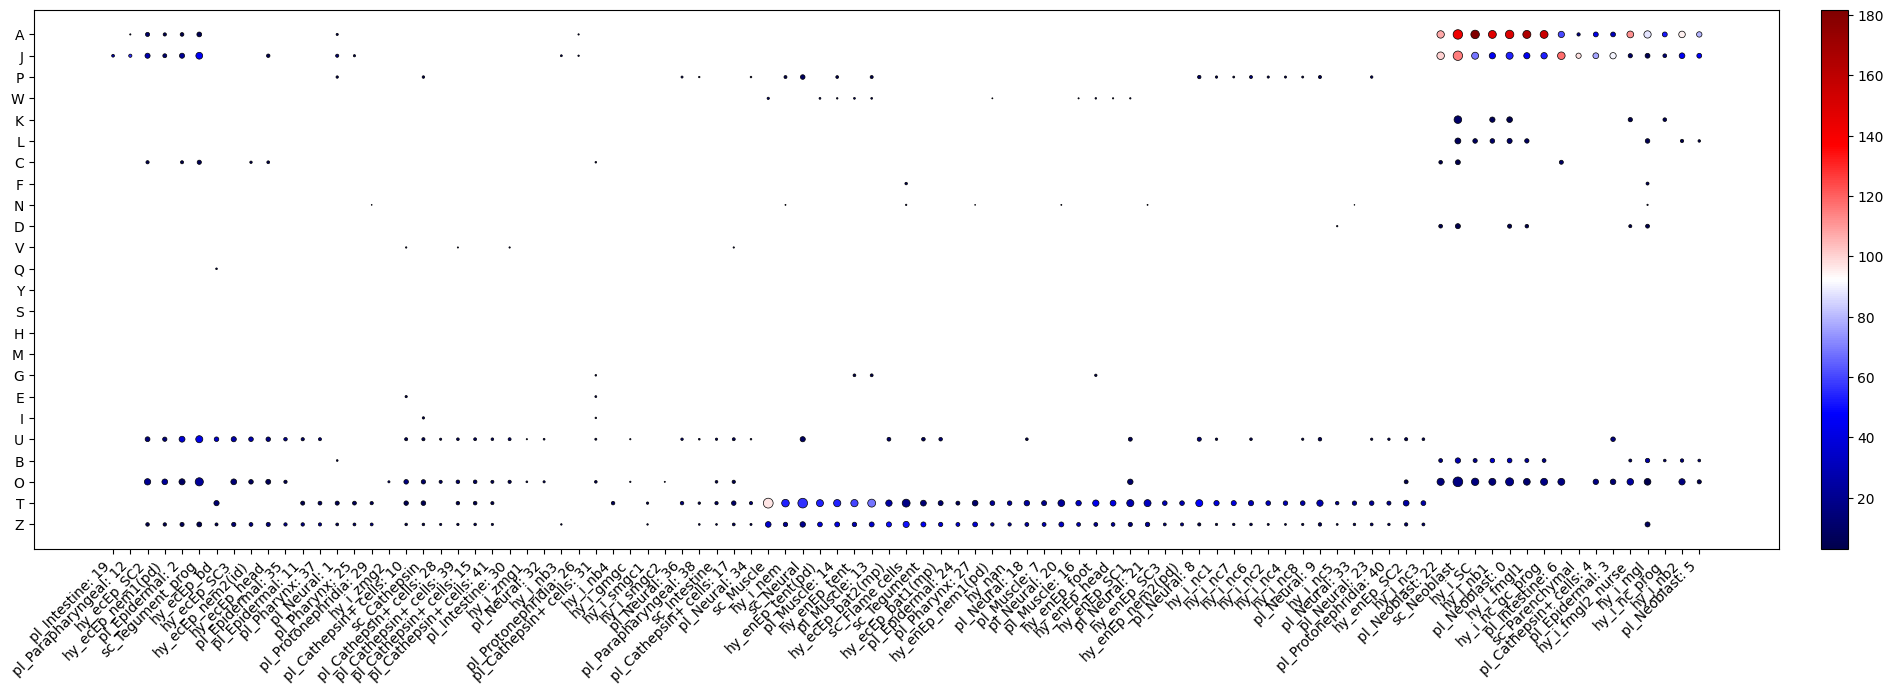

In [49]:
FE.plot_enrichment()

I've provided the hardcoded KOG table in `samap.analysis` to help interpret the axes if KOG terms were used for functional enrichment. Note that any functional annotations can be used for this analysis (such as GO terms).

In [50]:
from samap.analysis import _KOG_TABLE

In [51]:
_KOG_TABLE

{'A': 'RNA processing and modification',
 'B': 'Chromatin structure and dynamics',
 'C': 'Energy production and conversion',
 'D': 'Cell cycle control, cell division, chromosome partitioning',
 'E': 'Amino acid transport and metabolism',
 'F': 'Nucleotide transport and metabolism',
 'G': 'Carbohydrate transport and metabolism',
 'H': 'Coenzyme transport and metabolism',
 'I': 'Lipid transport and metabolism',
 'J': 'Translation, ribosomal structure and biogenesis',
 'K': 'Transcription',
 'L': 'Replication, recombination, and repair',
 'M': 'Cell wall membrane/envelope biogenesis',
 'N': 'Cell motility',
 'O': 'Post-translational modification, protein turnover, chaperones',
 'P': 'Inorganic ion transport and metabolism',
 'Q': 'Secondary metabolites biosynthesis, transport and catabolism',
 'R': 'General function prediction only',
 'S': 'Function unknown',
 'T': 'Signal transduction mechanisms',
 'U': 'Intracellular trafficking, secretion, and vesicular transport',
 'V': 'Defense mecha